# FC Barcelona — 2018–19 UEFA Champions League: Away Fragility & The Liverpool Collapse

**A Full Data Analysis Project**

---

> *"They didn't just lose a football match — they suffered a structural failure disguised as a scoreline."*

---

## Project Overview

This notebook conducts a professional-level statistical and tactical analysis of Barcelona's 2018–19 UCL campaign.
The central thesis: **Barcelona's brand of possession football masked deep fragilities away from home**, 
fragilities that became catastrophically exposed in the second leg at Anfield.

**Key questions we answer:**
1. How did Barcelona's performance metrics differ between home and away fixtures?
2. Was their possession dominance genuinely converting into goal threat?
3. What patterns in away matches predicted the Anfield collapse?
4. What happened mathematically on 7 May 2019?

---
## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor':   '#0d0d1a',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#ccccdd',
    'ytick.color':      '#ccccdd',
    'text.color':       '#ccccdd',
    'grid.color':       '#222244',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

BARCA_BLUE  = '#004d98'
BARCA_RED   = '#a50044'
BARCA_GOLD  = '#edbb00'
LIV_RED     = '#c8102e'
NEUTRAL     = '#8899aa'
HOME_COLOR  = BARCA_BLUE
AWAY_COLOR  = BARCA_RED

DATA_DIR   = '../data'
FIG_DIR    = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

print('Setup complete ✓')

Setup complete ✓


---
## 1. Data Loading & Preparation

In [2]:
# ── 1.1 Load core datasets ─────────────────────────────────────────────────
fixtures   = pd.read_csv(f'{DATA_DIR}/barca_ucl_2018_19_fixtures.csv',        encoding='utf-8-sig')
shoot_for  = pd.read_csv(f'{DATA_DIR}/barca_ucl_2018_19_shooting_for.csv',    encoding='utf-8-sig')
shoot_ag   = pd.read_csv(f'{DATA_DIR}/barca_ucl_2018_19_shooting_against.csv',encoding='utf-8-sig')

# Parse dates
for df in [fixtures, shoot_for, shoot_ag]:
    df['date'] = pd.to_datetime(df['date'])

# ── 1.2 Merge into one master match table ──────────────────────────────────
# Drop the redundant 'venue' column from shooting tables (use fixtures as truth)
shoot_for_clean = shoot_for.drop(columns=['venue'])
shoot_ag_clean  = shoot_ag.drop(columns=['venue', 'goals_against'])

matches = fixtures.merge(shoot_for_clean, on='date', how='left') \
                  .merge(shoot_ag_clean,  on='date', how='left')

# The fixtures already has goals_for / goals_against — drop duplicates from shooting
# (shoot_for carries 'goals' which equals goals_for)
# Drop 'goals' from shoot_for if present (same as goals_for in fixtures)
if 'goals' in matches.columns:
    matches = matches.drop(columns=['goals'])

# ── 1.3 Engineered metrics ─────────────────────────────────────────────────
matches['shot_efficiency']      = matches['goals_for']  / matches['shots']            # goals per shot
matches['shot_accuracy']        = matches['shots_on_target'] / matches['shots']       # SOT rate
matches['conversion_rate']      = matches['goals_for']  / matches['shots_on_target']  # goals per SOT
matches['opp_shot_efficiency']  = matches['goals_against'] / matches['shots_against']
matches['opp_shot_accuracy']    = matches['shots_on_target_against'] / matches['shots_against']
matches['shots_per_poss_pct']   = matches['shots'] / matches['possession']            # shots per 1% possession
matches['goal_diff']            = matches['goals_for'] - matches['goals_against']

# Match label for plots
matches['label'] = matches.apply(
    lambda r: f"{r['opponent']}\n({'H' if r['venue']=='Home' else 'A'})", axis=1
)
matches['label_short'] = matches.apply(
    lambda r: f"{r['opponent'][:4]}({'H' if r['venue']=='Home' else 'A'})", axis=1
)

print(f'Loaded {len(matches)} matches')
matches[['date','opponent','venue','result','goals_for','goals_against',
         'possession','shots','shots_on_target','shot_efficiency','shot_accuracy']].to_string(index=False)

Loaded 12 matches


'      date          opponent venue result  goals_for  goals_against  possession  shots  shots_on_target  shot_efficiency  shot_accuracy\n2018-09-18               PSV  Home      W          4              0          75     21                9         0.190476       0.428571\n2018-10-03         Tottenham  Away      W          4              2          61     13                8         0.307692       0.615385\n2018-10-24             Inter  Home      W          2              0          67     21               11         0.095238       0.523810\n2018-11-06             Inter  Away      D          1              1          65     26                8         0.038462       0.307692\n2018-11-28               PSV  Away      W          2              1          65     21                8         0.095238       0.380952\n2018-12-11         Tottenham  Home      D          1              1          49     14                3         0.071429       0.214286\n2019-02-19              Lyon  Away      

In [3]:
# ── 1.4 Load all player-level files ────────────────────────────────────────
player_files = {
    'Tottenham':       'player_match_stats_2018_10_03_tottenham.csv',
    'Inter':           'player_match_stats_2018_11_06_inter.csv',
    'PSV':             'player_match_stats_2018_11_28_psv.csv',
    'Lyon':            'player_match_stats_2019_02_19_lyon.csv',
    'Man Utd':         'player_match_stats_2019_04_10_manutd.csv',
    'Liverpool (H)':   'player_match_stats_2019_05_01_liverpool_home.csv',
    'Liverpool (A)':   'player_match_stats_2019_05_07_liverpool_away.csv',
}

team_files = {
    'Tottenham':       'team_match_stats_2018_10_03_tottenham.csv',
    'Inter':           'team_match_stats_2018_11_06_inter.csv',
    'PSV':             'team_match_stats_2018_11_28_psv.csv',
    'Lyon':            'team_match_stats_2019_02_19_lyon.csv',
    'Man Utd':         'team_match_stats_2019_04_10_manutd.csv',
    'Liverpool (H)':   'team_match_stats_2019_05_01_liverpool_home.csv',
    'Liverpool (A)':   'team_match_stats_2019_05_07_liverpool_away.csv',
}

player_dfs = {}
team_dfs   = {}

for key, fname in player_files.items():
    fpath = f'{DATA_DIR}/{fname}'
    try:
        df = pd.read_csv(fpath, encoding='utf-8-sig')
        if df.empty or df.shape[0] == 0:
            print(f'  [EMPTY] {key}')
        else:
            player_dfs[key] = df
            print(f'  Loaded player data: {key} — {len(df)} rows')
    except Exception as e:
        print(f'  [ERROR] {key}: {e}')

for key, fname in team_files.items():
    fpath = f'{DATA_DIR}/{fname}'
    try:
        df = pd.read_csv(fpath, encoding='utf-8-sig')
        if df.empty or df.shape[0] == 0:
            print(f'  [EMPTY] {key} team')
        else:
            team_dfs[key] = df
            print(f'  Loaded team data: {key} — {len(df)} rows')
    except Exception as e:
        print(f'  [ERROR] {key}: {e}')

# ── 1.5 Concatenate all player data (away matches only, excl. Tottenham away) ──
away_player_keys = ['Inter', 'PSV', 'Lyon', 'Man Utd', 'Liverpool (A)']
available_away_players = [k for k in away_player_keys if k in player_dfs]

all_players = pd.concat([df for k, df in player_dfs.items()], ignore_index=True)
all_players['date'] = pd.to_datetime(all_players['date'])
print(f'\nTotal player rows: {len(all_players)}')

  Loaded player data: Tottenham — 14 rows
  Loaded player data: Inter — 13 rows
  Loaded player data: PSV — 13 rows
  Loaded player data: Lyon — 13 rows
  Loaded player data: Man Utd — 14 rows
  Loaded player data: Liverpool (H) — 14 rows
  [ERROR] Liverpool (A): No columns to parse from file
  Loaded team data: Tottenham — 2 rows
  Loaded team data: Inter — 2 rows
  Loaded team data: PSV — 2 rows
  Loaded team data: Lyon — 2 rows
  Loaded team data: Man Utd — 2 rows
  Loaded team data: Liverpool (H) — 2 rows
  [ERROR] Liverpool (A): No columns to parse from file

Total player rows: 81


In [4]:
# ── 1.6 Build combined team stats table (all matches in team_dfs) ───────────
team_all = pd.concat([df[df['team']=='Barcelona'] for df in team_dfs.values()], ignore_index=True)
team_all['date'] = pd.to_datetime(team_all['date'])

# Merge with fixtures to get goals, possession, venue from master table
team_all = team_all.merge(
    matches[['date','goals_for','goals_against','venue','result','shot_efficiency',
             'shot_accuracy','shots_per_poss_pct','opp_shot_efficiency']],
    on='date', how='left', suffixes=('_tm', '')
)

# Recalculate defensive pressure proxy
team_all['def_pressure'] = team_all['tackles'] + team_all['interceptions']

print(team_all[['date','opponent','venue','poss_pct','shots','goals_for',
                 'def_pressure','shot_efficiency']].to_string(index=False))

      date          opponent venue  poss_pct  shots  goals_for  def_pressure  shot_efficiency
2018-10-03         Tottenham  Away        61     13          4            32         0.307692
2018-11-06             Inter  Away        65     26          1            18         0.038462
2018-11-28               PSV  Away        65     21          2            32         0.095238
2019-02-19              Lyon  Away        63     25          0            36         0.000000
2019-04-10 Manchester United  Away        67      6          1            14         0.166667
2019-05-01         Liverpool  Home        48     12          3            27         0.250000


---
## 2. Exploratory Data Analysis — Home vs Away

In [5]:
# ── 2.1 Summary statistics: Home vs Away ────────────────────────────────────
home_df = matches[matches['venue'] == 'Home']
away_df = matches[matches['venue'] == 'Away']

metrics = ['goals_for','goals_against','shots','shots_on_target',
           'possession','shot_efficiency','shot_accuracy','shots_per_poss_pct']

summary = pd.DataFrame({
    'Home (mean)': home_df[metrics].mean().round(3),
    'Away (mean)': away_df[metrics].mean().round(3),
    'Δ (Away–Home)': (away_df[metrics].mean() - home_df[metrics].mean()).round(3),
})

print('=== HOME vs AWAY: Mean Metrics ===')
print(summary.to_string())

=== HOME vs AWAY: Mean Metrics ===
                    Home (mean)  Away (mean)  Δ (Away–Home)
goals_for                 3.000        1.333         -1.667
goals_against             0.333        1.333          1.000
shots                    16.667       16.500         -0.167
shots_on_target           7.333        6.167         -1.167
possession               60.000       63.000          3.000
shot_efficiency           0.184        0.101         -0.082
shot_accuracy             0.429        0.438          0.010
shots_per_poss_pct        0.279        0.260         -0.018


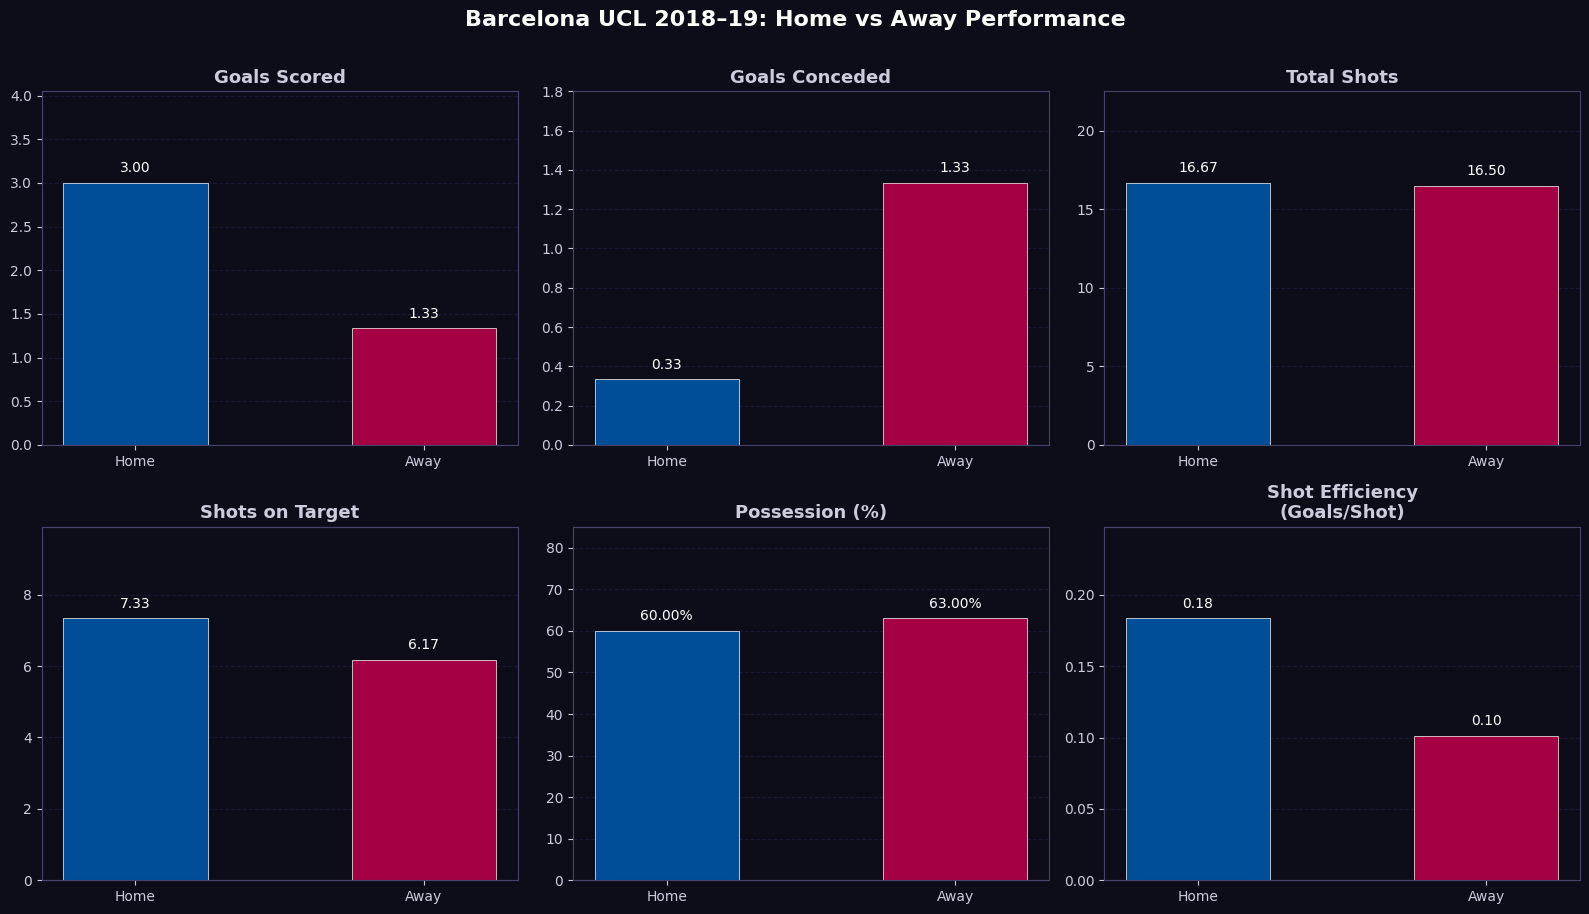

Figure saved.


In [6]:
# ── 2.2 Grouped bar chart: Home vs Away ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Barcelona UCL 2018–19: Home vs Away Performance', 
             fontsize=16, fontweight='bold', color='white', y=1.01)

plot_metrics = [
    ('goals_for',         'Goals Scored',              ''),
    ('goals_against',     'Goals Conceded',            ''),
    ('shots',             'Total Shots',               ''),
    ('shots_on_target',   'Shots on Target',           ''),
    ('possession',        'Possession (%)',             '%'),
    ('shot_efficiency',   'Shot Efficiency\n(Goals/Shot)', ''),
]

for ax, (col, title, unit) in zip(axes.flat, plot_metrics):
    vals = [home_df[col].mean(), away_df[col].mean()]
    bars = ax.bar(['Home', 'Away'], vals, color=[HOME_COLOR, AWAY_COLOR],
                  width=0.5, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.35)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.03,
                f'{val:.2f}{unit}', ha='center', va='bottom', fontsize=10, color='white')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_home_vs_away_overview.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Figure saved.')

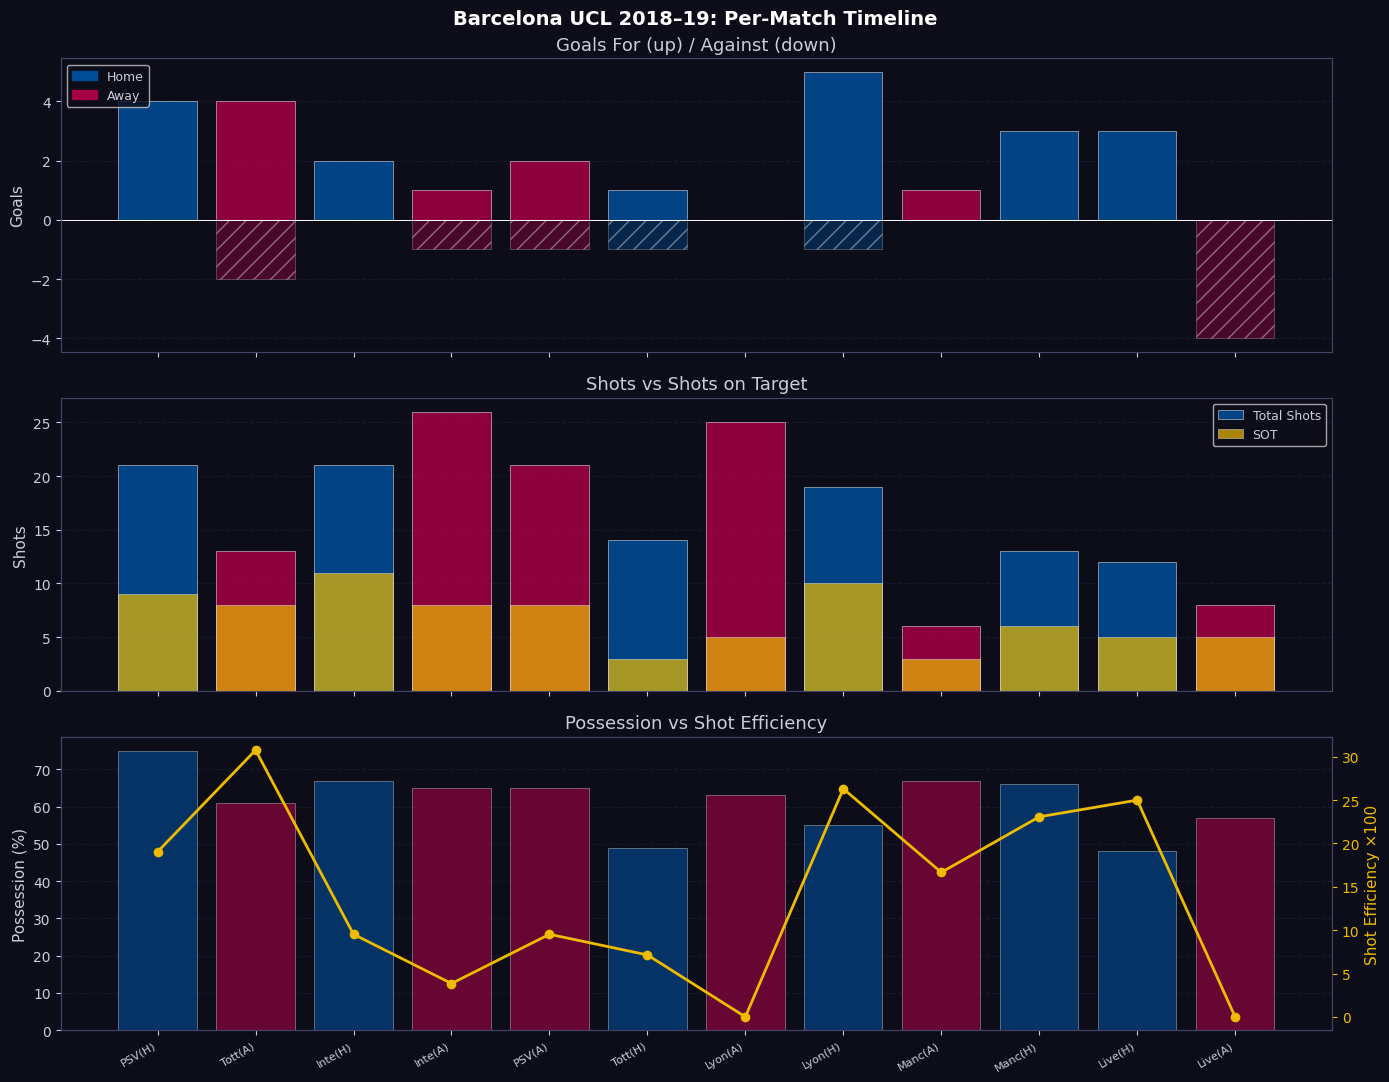

In [7]:
# ── 2.3 Per-match timeline ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Barcelona UCL 2018–19: Per-Match Timeline', 
             fontsize=14, fontweight='bold', color='white')

x      = range(len(matches))
xlabs  = matches['label_short'].tolist()
colors = [HOME_COLOR if v == 'Home' else AWAY_COLOR for v in matches['venue']]

# Panel 1: Goals
ax = axes[0]
ax.bar(x, matches['goals_for'],     color=colors, alpha=0.85, label='Goals For',     edgecolor='white', linewidth=0.4)
ax.bar(x, -matches['goals_against'],color=colors, alpha=0.40, label='Goals Against', edgecolor='white', linewidth=0.4, hatch='//')
ax.axhline(0, color='white', linewidth=0.7)
ax.set_ylabel('Goals')
ax.set_title('Goals For (up) / Against (down)')
ax.yaxis.grid(True); ax.set_axisbelow(True)

# Panel 2: Shots
ax = axes[1]
ax.bar(x, matches['shots'],           color=colors, alpha=0.85, label='Total Shots',     edgecolor='white', linewidth=0.4)
ax.bar(x, matches['shots_on_target'], color=BARCA_GOLD, alpha=0.70, label='SOT',          edgecolor='white', linewidth=0.4)
ax.set_ylabel('Shots')
ax.set_title('Shots vs Shots on Target')
ax.legend(fontsize=9)
ax.yaxis.grid(True); ax.set_axisbelow(True)

# Panel 3: Possession & Shot Efficiency
ax = axes[2]
ax2 = ax.twinx()
ax.bar(x, matches['possession'], color=colors, alpha=0.6, edgecolor='white', linewidth=0.4)
ax2.plot(x, matches['shot_efficiency']*100, 'o-', color=BARCA_GOLD, linewidth=2, markersize=6, label='Shot Eff. ×100')
ax.set_ylabel('Possession (%)')
ax2.set_ylabel('Shot Efficiency ×100', color=BARCA_GOLD)
ax2.tick_params(colors=BARCA_GOLD)
ax.set_title('Possession vs Shot Efficiency')
ax.set_xticks(list(x))
ax.set_xticklabels(xlabs, fontsize=8, rotation=30, ha='right')
ax.yaxis.grid(True); ax.set_axisbelow(True)

legend_elements = [
    mpatches.Patch(color=HOME_COLOR, label='Home'),
    mpatches.Patch(color=AWAY_COLOR, label='Away'),
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_timeline.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

---
## 3. Tactical Style — Possession vs Chance Creation

The central tension in Barcelona's style: **high possession does not guarantee goal threat**.
We quantify this by plotting possession against shots and shot efficiency.

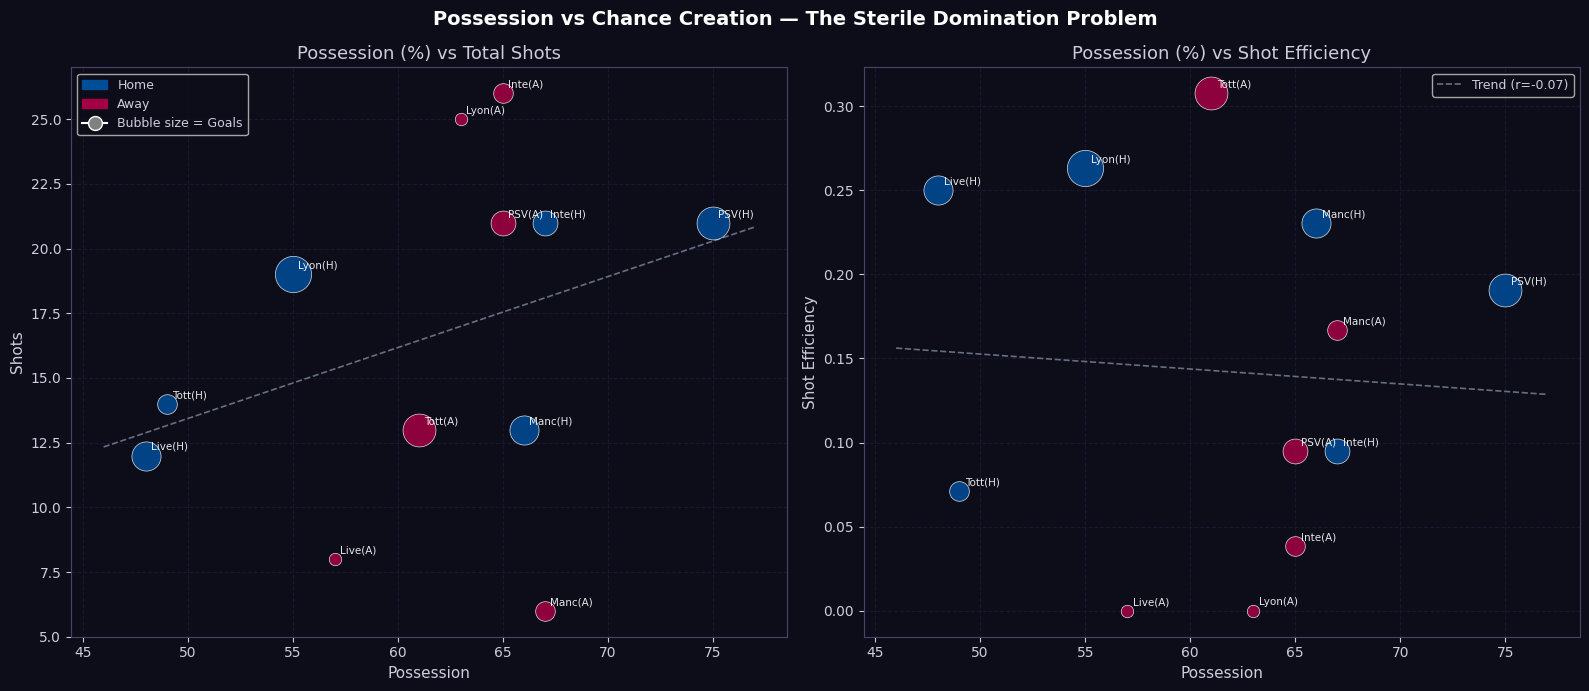

In [8]:
# ── 3.1 Scatter: Possession vs Shots (bubble = goals scored) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Possession vs Chance Creation — The Sterile Domination Problem',
             fontsize=14, fontweight='bold', color='white')

for ax, (xcol, ycol, title) in zip(axes, [
    ('possession', 'shots',          'Possession (%) vs Total Shots'),
    ('possession', 'shot_efficiency','Possession (%) vs Shot Efficiency'),
]):
    for _, row in matches.iterrows():
        color  = HOME_COLOR if row['venue'] == 'Home' else AWAY_COLOR
        size   = row['goals_for'] * 120 + 80
        ax.scatter(row[xcol], row[ycol], s=size, color=color, alpha=0.85,
                   edgecolors='white', linewidth=0.5, zorder=3)
        ax.annotate(row['label_short'],
                    xy=(row[xcol], row[ycol]),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=7.5, color='white', alpha=0.9)

    # Regression line
    x_vals = matches[xcol].values
    y_vals = matches[ycol].values
    m, b   = np.polyfit(x_vals, y_vals, 1)
    xline  = np.linspace(x_vals.min()-2, x_vals.max()+2, 100)
    ax.plot(xline, m*xline + b, '--', color=NEUTRAL, linewidth=1.2, alpha=0.7, label=f'Trend (r={np.corrcoef(x_vals,y_vals)[0,1]:.2f})')

    ax.set_xlabel(xcol.replace('_',' ').title())
    ax.set_ylabel(ycol.replace('_',' ').title())
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True); ax.xaxis.grid(True); ax.set_axisbelow(True)

legend_elements = [
    mpatches.Patch(color=HOME_COLOR, label='Home'),
    mpatches.Patch(color=AWAY_COLOR, label='Away'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markersize=10, label='Bubble size = Goals'),
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_possession_vs_creation.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

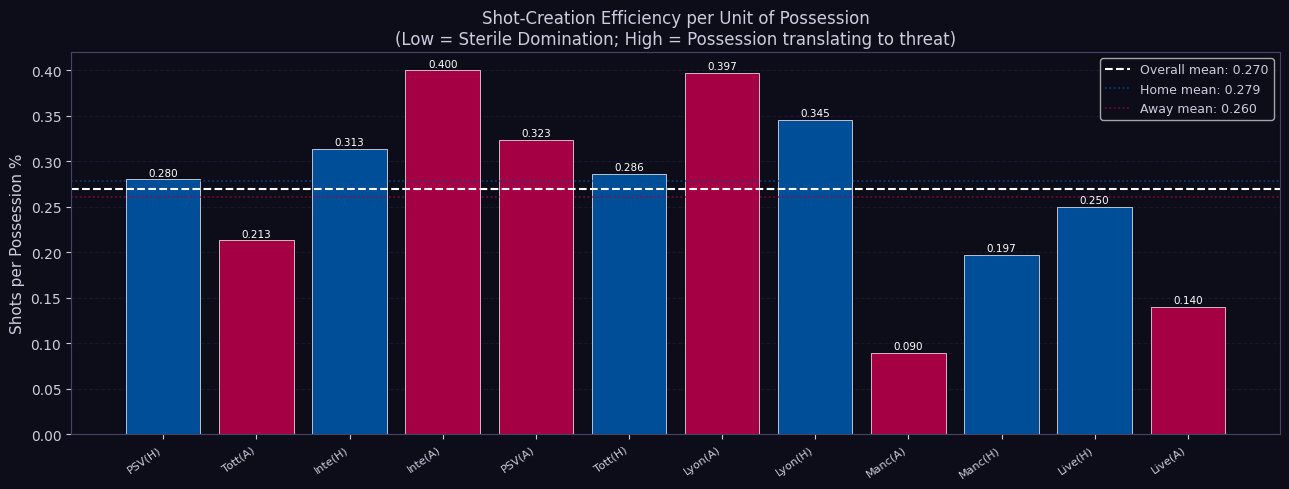

Home shots/poss% mean: 0.279
Away shots/poss% mean: 0.260
Difference: -0.018  (-6.5%)


In [9]:
# ── 3.2 Shots per possession-percent: the 'weight' metric ────────────────────
# shots_per_poss_pct tells us: for every 1% of possession, how many shots did they generate?
# Low value → possession-heavy but not converting it into shots

fig, ax = plt.subplots(figsize=(13, 5))

colors = [HOME_COLOR if v == 'Home' else AWAY_COLOR for v in matches['venue']]
bars = ax.bar(range(len(matches)), matches['shots_per_poss_pct'],
              color=colors, edgecolor='white', linewidth=0.5)

# Grand mean line
grand_mean = matches['shots_per_poss_pct'].mean()
home_mean  = home_df['shots_per_poss_pct'].mean()
away_mean  = away_df['shots_per_poss_pct'].mean()

ax.axhline(grand_mean, color='white',    linewidth=1.5, linestyle='--', label=f'Overall mean: {grand_mean:.3f}')
ax.axhline(home_mean,  color=HOME_COLOR, linewidth=1.2, linestyle=':',  label=f'Home mean: {home_mean:.3f}', alpha=0.8)
ax.axhline(away_mean,  color=AWAY_COLOR, linewidth=1.2, linestyle=':',  label=f'Away mean: {away_mean:.3f}', alpha=0.8)

for i, (bar, row) in enumerate(zip(bars, matches.itertuples())):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{row.shots_per_poss_pct:.3f}', ha='center', va='bottom', fontsize=7.5, color='white')

ax.set_xticks(range(len(matches)))
ax.set_xticklabels(matches['label_short'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Shots per Possession %')
ax.set_title('Shot-Creation Efficiency per Unit of Possession\n'
             '(Low = Sterile Domination; High = Possession translating to threat)', fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_shots_per_poss.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print(f'Home shots/poss% mean: {home_mean:.3f}')
print(f'Away shots/poss% mean: {away_mean:.3f}')
print(f'Difference: {away_mean - home_mean:+.3f}  ({((away_mean-home_mean)/home_mean)*100:+.1f}%)')

---
## 4. Away Fragility Analysis — Focused Deep Dive

In [10]:
# ── 4.1 Away matches only: key metrics table ─────────────────────────────────
away_matches = matches[matches['venue'] == 'Away'].copy()
away_matches['label_full'] = away_matches.apply(
    lambda r: f"{r['opponent']} (A)  [{r['goals_for']}–{r['goals_against']}]", axis=1
)

display_cols = ['opponent','result','goals_for','goals_against','possession',
                'shots','shots_on_target','shot_efficiency','shot_accuracy',
                'shots_per_poss_pct']

print('=== AWAY MATCHES DETAILED ===')
print(away_matches[display_cols].to_string(index=False))

=== AWAY MATCHES DETAILED ===
         opponent result  goals_for  goals_against  possession  shots  shots_on_target  shot_efficiency  shot_accuracy  shots_per_poss_pct
        Tottenham      W          4              2          61     13                8         0.307692       0.615385            0.213115
            Inter      D          1              1          65     26                8         0.038462       0.307692            0.400000
              PSV      W          2              1          65     21                8         0.095238       0.380952            0.323077
             Lyon      D          0              0          63     25                5         0.000000       0.200000            0.396825
Manchester United      W          1              0          67      6                3         0.166667       0.500000            0.089552
        Liverpool      L          0              4          57      8                5         0.000000       0.625000            0.1403

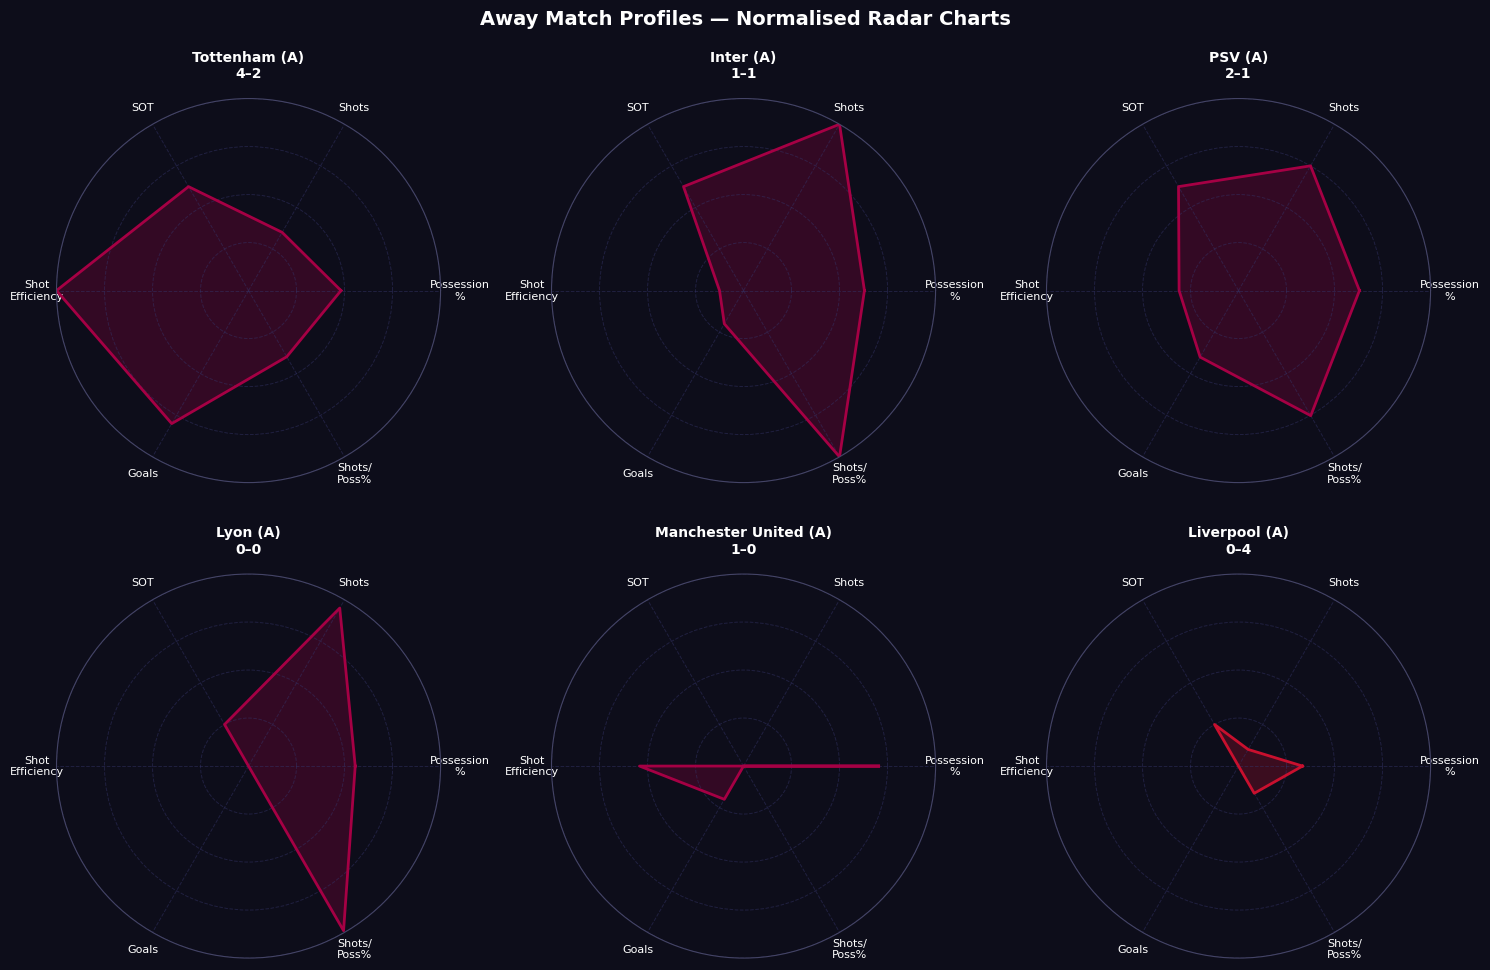

In [11]:
# ── 4.2 Radar chart: Away match profiles ────────────────────────────────────
# Normalize each metric to 0–1 across all matches for radar

radar_metrics = ['possession', 'shots', 'shots_on_target', 'shot_efficiency',
                 'goals_for', 'shots_per_poss_pct']
radar_labels  = ['Possession\n%', 'Shots', 'SOT', 'Shot\nEfficiency',
                 'Goals', 'Shots/\nPoss%']

# We'll show the 5 key away matches + Liverpool Home for reference
key_matches = away_matches.copy()
lpool_home  = matches[matches['opponent'] == 'Liverpool'].iloc[0:1].copy()
plot_df     = pd.concat([key_matches, lpool_home], ignore_index=True)

# Min-max normalise across ALL matches
for col in radar_metrics:
    mn, mx = matches[col].min(), matches[col].max()
    plot_df[f'{col}_norm'] = (plot_df[col] - mn) / (mx - mn + 1e-9)

norm_cols = [f'{m}_norm' for m in radar_metrics]
N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(polar=True))
fig.suptitle('Away Match Profiles — Normalised Radar Charts', 
             fontsize=14, fontweight='bold', color='white')

palette = [AWAY_COLOR, AWAY_COLOR, AWAY_COLOR, AWAY_COLOR, AWAY_COLOR, LIV_RED]

for ax, (_, row), col in zip(axes.flat, plot_df.iterrows(), palette):
    vals = [row[c] for c in norm_cols]
    vals += vals[:1]

    ax.plot(angles, vals, color=col, linewidth=2)
    ax.fill(angles, vals, color=col, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=8, color='white')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([])
    ax.grid(color='#333366', linewidth=0.7)
    ax.set_facecolor('#0d0d1a')
    venue_tag = '(H)' if row['venue'] == 'Home' else '(A)'
    ax.set_title(f"{row['opponent']} {venue_tag}\n{row['goals_for']}–{row['goals_against']}",
                 fontsize=10, fontweight='bold', pad=15, color='white')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_radar_away_profiles.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

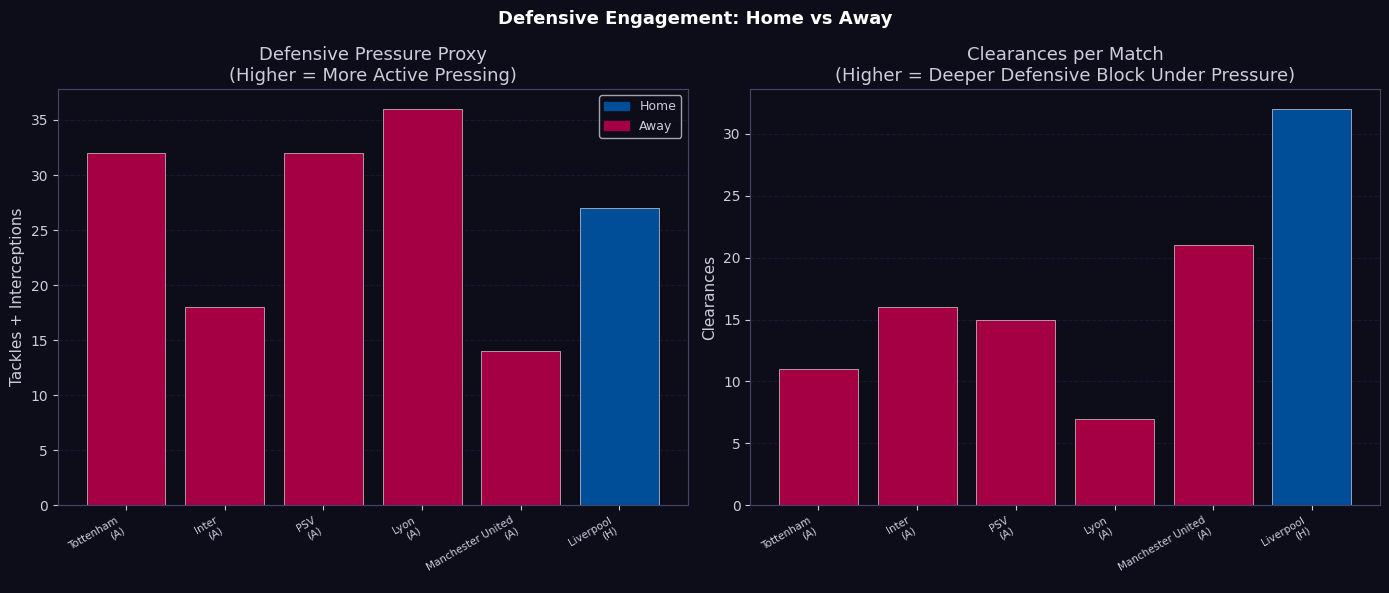

In [12]:
# ── 4.3 Defensive actions: Away vs Home ─────────────────────────────────────
# Use team-level detail (tackles + interceptions)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Defensive Engagement: Home vs Away', fontsize=13, fontweight='bold', color='white')

# Panel A: Tackles + Interceptions
ax = axes[0]
team_all_sorted = team_all.sort_values('date')
colors = [HOME_COLOR if v == 'Home' else AWAY_COLOR for v in team_all_sorted['venue']]

bars = ax.bar(range(len(team_all_sorted)), team_all_sorted['def_pressure'],
              color=colors, edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(team_all_sorted)))
ax.set_xticklabels([f"{r['opponent']}\n({'H' if r['venue']=='Home' else 'A'})"
                    for _, r in team_all_sorted.iterrows()],
                   fontsize=7.5, rotation=30, ha='right')
ax.set_ylabel('Tackles + Interceptions')
ax.set_title('Defensive Pressure Proxy\n(Higher = More Active Pressing)')
ax.yaxis.grid(True); ax.set_axisbelow(True)

# Panel B: Clearances
ax = axes[1]
bars = ax.bar(range(len(team_all_sorted)), team_all_sorted['clearances'],
              color=colors, edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(team_all_sorted)))
ax.set_xticklabels([f"{r['opponent']}\n({'H' if r['venue']=='Home' else 'A'})"
                    for _, r in team_all_sorted.iterrows()],
                   fontsize=7.5, rotation=30, ha='right')
ax.set_ylabel('Clearances')
ax.set_title('Clearances per Match\n(Higher = Deeper Defensive Block Under Pressure)')
ax.yaxis.grid(True); ax.set_axisbelow(True)

legend_elements = [
    mpatches.Patch(color=HOME_COLOR, label='Home'),
    mpatches.Patch(color=AWAY_COLOR, label='Away'),
]
axes[0].legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_defensive_actions.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

---
## 5. Case Studies — Inter, Lyon & Manchester United Away

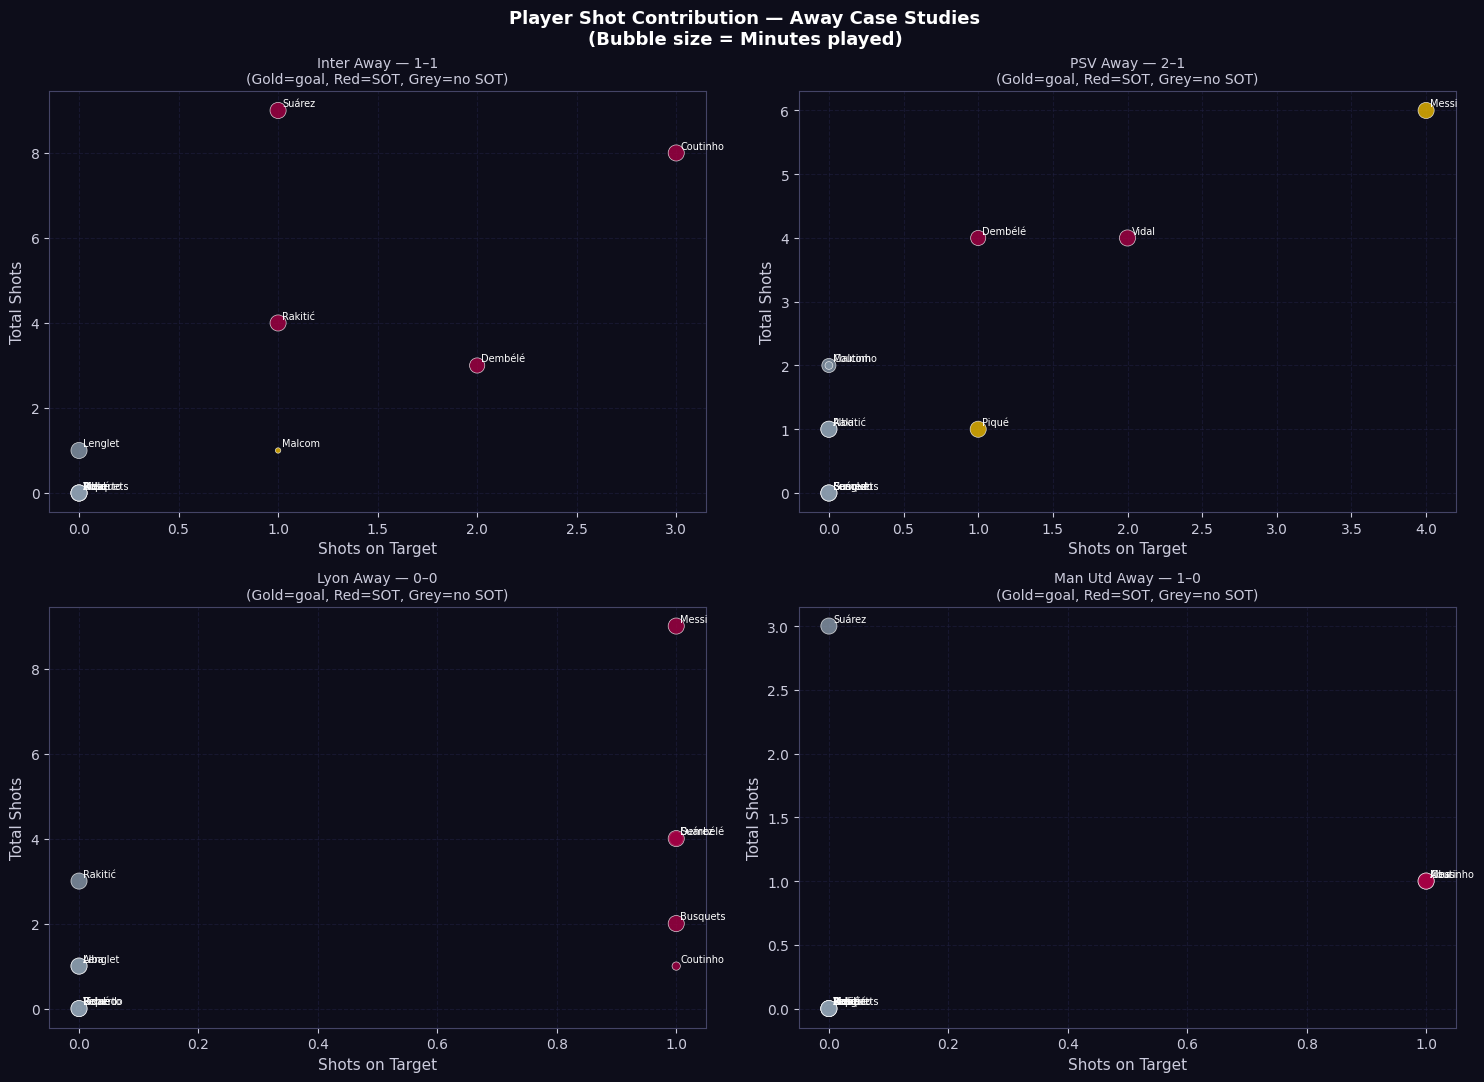

In [13]:
# ── 5.1 Player-level shots: Away case studies ────────────────────────────────
case_study_keys = ['Inter', 'PSV', 'Lyon', 'Man Utd']
case_dfs = {k: player_dfs[k] for k in case_study_keys if k in player_dfs}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Player Shot Contribution — Away Case Studies\n(Bubble size = Minutes played)',
             fontsize=13, fontweight='bold', color='white')

result_map = {'Inter': '1–1', 'PSV': '2–1', 'Lyon': '0–0', 'Man Utd': '1–0'}

for ax, (key, df) in zip(axes.flat, case_dfs.items()):
    df = df.copy()
    df = df.sort_values('shots', ascending=False).head(12)
    colors_p = [BARCA_GOLD if g > 0 else BARCA_RED if sot > 0 else NEUTRAL
                for g, sot in zip(df.get('goals', [0]*len(df)), df['shots_on_target'])]
    scatter = ax.scatter(df['shots_on_target'], df['shots'],
                         s=df['minutes']*1.5, c=colors_p, alpha=0.8,
                         edgecolors='white', linewidth=0.5, zorder=3)
    for _, row in df.iterrows():
        name = row['player'].split()[-1]  # last name only
        ax.annotate(name, (row['shots_on_target'], row['shots']),
                    xytext=(3, 3), textcoords='offset points', fontsize=7, color='white')
    ax.set_xlabel('Shots on Target')
    ax.set_ylabel('Total Shots')
    ax.set_title(f'{key} Away — {result_map.get(key,"")}\n(Gold=goal, Red=SOT, Grey=no SOT)', fontsize=10)
    ax.yaxis.grid(True); ax.xaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_player_shots_case_studies.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [14]:
# ── 5.2 Numerical summary of case study away matches ─────────────────────────
print('\n=== AWAY CASE STUDY METRICS ===')
case_rows = away_matches[away_matches['opponent'].isin(['Inter','PSV','Lyon','Manchester United'])]

for _, row in case_rows.iterrows():
    shots = row['shots']
    sot   = row['shots_on_target']
    goals = row['goals_for']
    poss  = row['possession']
    eff   = row['shot_efficiency']
    sppp  = row['shots_per_poss_pct']

    print(f"\n{row['opponent']} (Away) [{row['goals_for']}–{row['goals_against']}]")
    print(f"  Possession:      {poss}%")
    print(f"  Shots / SOT:     {shots} / {sot}  (accuracy = {sot/shots*100:.1f}%)")
    print(f"  Goals scored:    {goals}")
    print(f"  Shot efficiency: {eff:.3f}  (goals per shot)")
    print(f"  Shots/poss%:     {sppp:.3f}")
    
    # Shot volume diagnosis
    if shots >= 20 and goals <= 1:
        print(f"  ⚠️  HIGH VOLUME, LOW CONVERSION — classic sterile domination")
    elif shots < 10:
        print(f"  ⚠️  LOW SHOT VOLUME — possession not generating threat")


=== AWAY CASE STUDY METRICS ===

Inter (Away) [1–1]
  Possession:      65%
  Shots / SOT:     26 / 8  (accuracy = 30.8%)
  Goals scored:    1
  Shot efficiency: 0.038  (goals per shot)
  Shots/poss%:     0.400
  ⚠️  HIGH VOLUME, LOW CONVERSION — classic sterile domination

PSV (Away) [2–1]
  Possession:      65%
  Shots / SOT:     21 / 8  (accuracy = 38.1%)
  Goals scored:    2
  Shot efficiency: 0.095  (goals per shot)
  Shots/poss%:     0.323

Lyon (Away) [0–0]
  Possession:      63%
  Shots / SOT:     25 / 5  (accuracy = 20.0%)
  Goals scored:    0
  Shot efficiency: 0.000  (goals per shot)
  Shots/poss%:     0.397
  ⚠️  HIGH VOLUME, LOW CONVERSION — classic sterile domination

Manchester United (Away) [1–0]
  Possession:      67%
  Shots / SOT:     6 / 3  (accuracy = 50.0%)
  Goals scored:    1
  Shot efficiency: 0.167  (goals per shot)
  Shots/poss%:     0.090
  ⚠️  LOW SHOT VOLUME — possession not generating threat


---
## 6. The Liverpool Collapse — Deep Analysis

In [15]:
# ── 6.1 Side-by-side: Liverpool Leg 1 vs Leg 2 ──────────────────────────────
lpool_h = matches[(matches['opponent'] == 'Liverpool') & (matches['venue'] == 'Home')].iloc[0]
lpool_a = matches[(matches['opponent'] == 'Liverpool') & (matches['venue'] == 'Away')].iloc[0]

print('=== LIVERPOOL — LEG BY LEG ===')
comparison_cols = ['goals_for','goals_against','possession','shots','shots_on_target',
                   'shot_efficiency','shot_accuracy','shots_per_poss_pct',
                   'shots_against','shots_on_target_against','opp_shot_efficiency']

comp = pd.DataFrame({
    'Leg 1 (H) 3–0': lpool_h[comparison_cols],
    'Leg 2 (A) 0–4': lpool_a[comparison_cols],
}).T

print(comp.to_string())

=== LIVERPOOL — LEG BY LEG ===
              goals_for goals_against possession shots shots_on_target shot_efficiency shot_accuracy shots_per_poss_pct shots_against shots_on_target_against opp_shot_efficiency
Leg 1 (H) 3–0         3             0         48    12               5            0.25      0.416667               0.25            15                       5                 0.0
Leg 2 (A) 0–4         0             4         57     8               5             0.0         0.625           0.140351            14                       8            0.285714


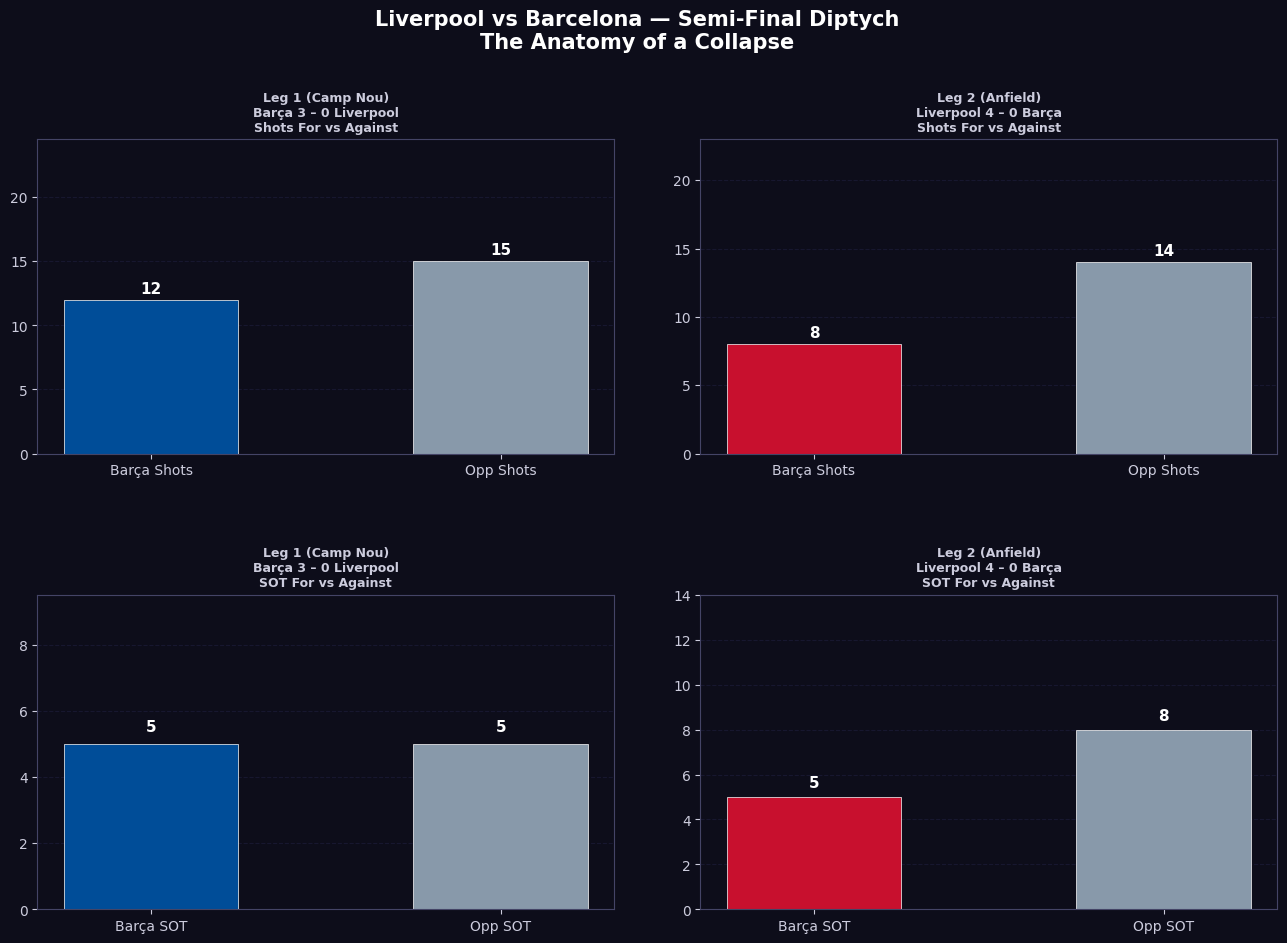

In [16]:
# ── 6.2 Visual: Liverpool Diptych ───────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Liverpool vs Barcelona — Semi-Final Diptych\nThe Anatomy of a Collapse',
             fontsize=15, fontweight='bold', color='white', y=1.01)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

leg_data = {
    'Leg 1 (Camp Nou)\nBarça 3 – 0 Liverpool': {
        'color': HOME_COLOR,
        'row': lpool_h,
        'col_start': 0
    },
    'Leg 2 (Anfield)\nLiverpool 4 – 0 Barça': {
        'color': LIV_RED,
        'row': lpool_a,
        'col_start': 2
    }
}

metric_pairs = [
    ('Shots For vs Against',
     [('shots', 'Barça Shots'), ('shots_against', 'Opp Shots')]),
    ('SOT For vs Against',
     [('shots_on_target', 'Barça SOT'), ('shots_on_target_against', 'Opp SOT')]),
]

for col_offset, (leg_title, leg_info) in enumerate(leg_data.items()):
    row_data = leg_info['row']
    base_color = leg_info['color']
    cs = leg_info['col_start']

    for row_idx, (chart_title, metric_list) in enumerate(metric_pairs):
        ax = fig.add_subplot(gs[row_idx, cs:cs+2])
        labels_m = [m[1] for m in metric_list]
        values   = [row_data[m[0]] for m in metric_list]
        bar_cols = [base_color, NEUTRAL]
        bars = ax.bar(labels_m, values, color=bar_cols, edgecolor='white', linewidth=0.5, width=0.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(int(val)), ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')
        ax.set_ylim(0, max(values)*1.5 + 2)
        ax.set_title(f'{leg_title}\n{chart_title}', fontsize=9, fontweight='bold')
        ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.savefig(f'{FIG_DIR}/08_liverpool_diptych.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

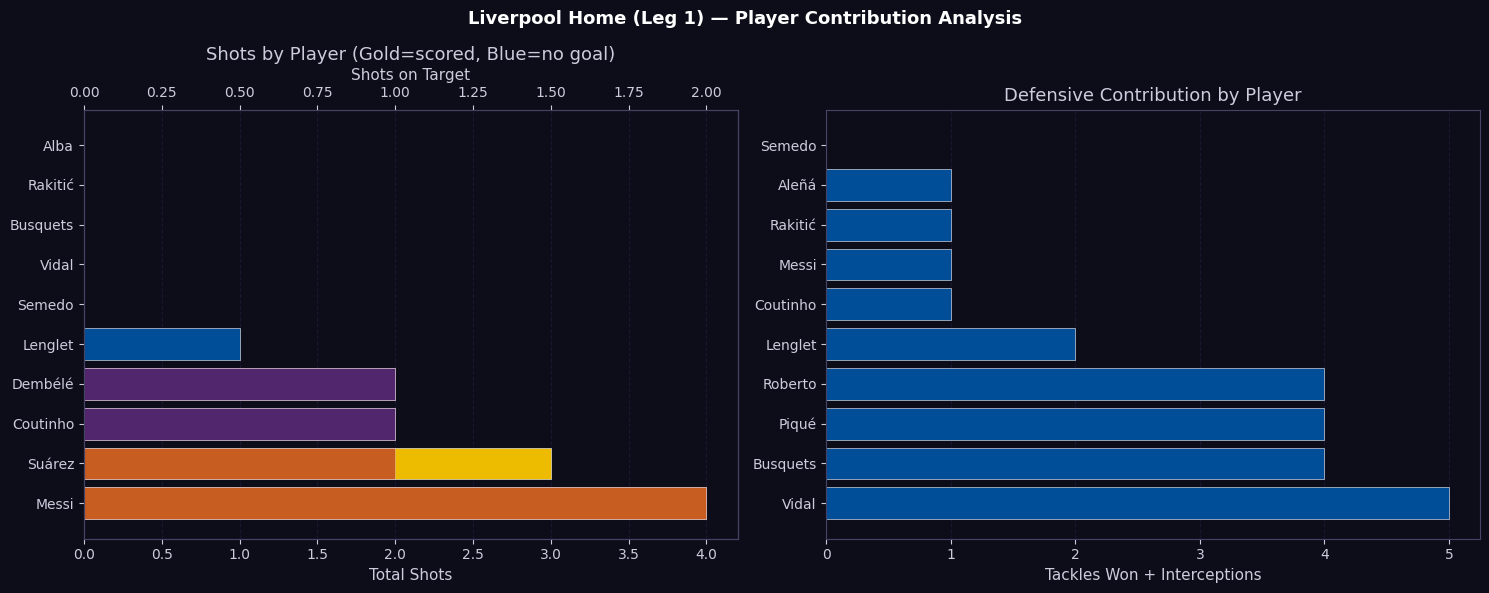

In [17]:
# ── 6.3 Player-level analysis: Liverpool Home (Leg 1) ────────────────────────
lh_players = player_dfs.get('Liverpool (H)', pd.DataFrame())

if not lh_players.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Liverpool Home (Leg 1) — Player Contribution Analysis',
                 fontsize=13, fontweight='bold', color='white')

    # Top shooters
    ax = axes[0]
    top = lh_players.sort_values('shots', ascending=False).head(10)
    bar_colors = [BARCA_GOLD if g > 0 else BARCA_BLUE for g in top.get('goals', [0]*len(top))]
    bars = ax.barh(top['player'].apply(lambda x: x.split()[-1]),
                   top['shots'], color=bar_colors, edgecolor='white', linewidth=0.4)
    ax2 = ax.twiny()
    ax2.barh(top['player'].apply(lambda x: x.split()[-1]),
             top['shots_on_target'], color=BARCA_RED, alpha=0.5, edgecolor='white',
             linewidth=0.4, label='SOT')
    ax.set_xlabel('Total Shots')
    ax2.set_xlabel('Shots on Target')
    ax.set_title('Shots by Player (Gold=scored, Blue=no goal)')
    ax.xaxis.grid(True); ax.set_axisbelow(True)

    # Defensive contribution
    ax = axes[1]
    lh_players['def_contrib'] = lh_players['tackles_won'] + lh_players['interceptions']
    top_def = lh_players.sort_values('def_contrib', ascending=False).head(10)
    ax.barh(top_def['player'].apply(lambda x: x.split()[-1]),
            top_def['def_contrib'], color=BARCA_BLUE, edgecolor='white', linewidth=0.4, label='Tackles+Int')
    ax.set_xlabel('Tackles Won + Interceptions')
    ax.set_title('Defensive Contribution by Player')
    ax.xaxis.grid(True); ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/09_liverpool_home_players.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()

In [18]:
# ── 6.4 Mathematical comparison: efficiency collapse ────────────────────────
print('=== MATHEMATICAL ANALYSIS: LIVERPOOL COLLAPSE ===')
print()

# Leg 1 numbers
leg1_shots    = lpool_h['shots']
leg1_sot      = lpool_h['shots_on_target']
leg1_goals    = lpool_h['goals_for']
leg1_poss     = lpool_h['possession']
leg1_eff      = lpool_h['shot_efficiency']
leg1_acc      = lpool_h['shot_accuracy']

# Leg 2 numbers
leg2_shots    = lpool_a['shots']
leg2_sot      = lpool_a['shots_on_target']
leg2_goals    = lpool_a['goals_for']
leg2_poss     = lpool_a['possession']
leg2_eff      = lpool_a['shot_efficiency']
leg2_acc      = lpool_a['shot_accuracy']

print(f"{'Metric':<35} {'Leg 1 (H)':<15} {'Leg 2 (A)':<15} {'Change':<15}")
print('-' * 80)
rows = [
    ('Goals scored',         leg1_goals,  leg2_goals,  ''),
    ('Shots',                leg1_shots,  leg2_shots,  ''),
    ('Shots on Target',      leg1_sot,    leg2_sot,    ''),
    ('Possession (%)',        leg1_poss,   leg2_poss,   ''),
    ('Shot Efficiency',      leg1_eff,    leg2_eff,    ''),
    ('Shot Accuracy',         leg1_acc,    leg2_acc,    ''),
    ('Shots per Poss%',      lpool_h['shots_per_poss_pct'], lpool_a['shots_per_poss_pct'], ''),
]

for label, v1, v2, _ in rows:
    change = v2 - v1
    pct    = (change / v1 * 100) if v1 != 0 else float('nan')
    print(f"{label:<35} {v1:<15.3f} {v2:<15.3f} {change:+.3f} ({pct:+.1f}%)")

print()
print('-- Opponent Stats --')
print(f"Liverpool shots:  Leg1={lpool_h['shots_against']:.0f},  Leg2={lpool_a['shots_against']:.0f}")
print(f"Liverpool SOT:    Leg1={lpool_h['shots_on_target_against']:.0f},  Leg2={lpool_a['shots_on_target_against']:.0f}")
print(f"Liverpool goals:  Leg1={lpool_h['goals_against']:.0f},  Leg2={lpool_a['goals_against']:.0f}")
print(f"Liverpool eff:    Leg1={lpool_h['opp_shot_efficiency']:.3f}, Leg2={lpool_a['opp_shot_efficiency']:.3f}")

=== MATHEMATICAL ANALYSIS: LIVERPOOL COLLAPSE ===

Metric                              Leg 1 (H)       Leg 2 (A)       Change         
--------------------------------------------------------------------------------
Goals scored                        3.000           0.000           -3.000 (-100.0%)
Shots                               12.000          8.000           -4.000 (-33.3%)
Shots on Target                     5.000           5.000           +0.000 (+0.0%)
Possession (%)                      48.000          57.000          +9.000 (+18.8%)
Shot Efficiency                     0.250           0.000           -0.250 (-100.0%)
Shot Accuracy                       0.417           0.625           +0.208 (+50.0%)
Shots per Poss%                     0.250           0.140           -0.110 (-43.9%)

-- Opponent Stats --
Liverpool shots:  Leg1=15,  Leg2=14
Liverpool SOT:    Leg1=5,  Leg2=8
Liverpool goals:  Leg1=0,  Leg2=4
Liverpool eff:    Leg1=0.000, Leg2=0.286


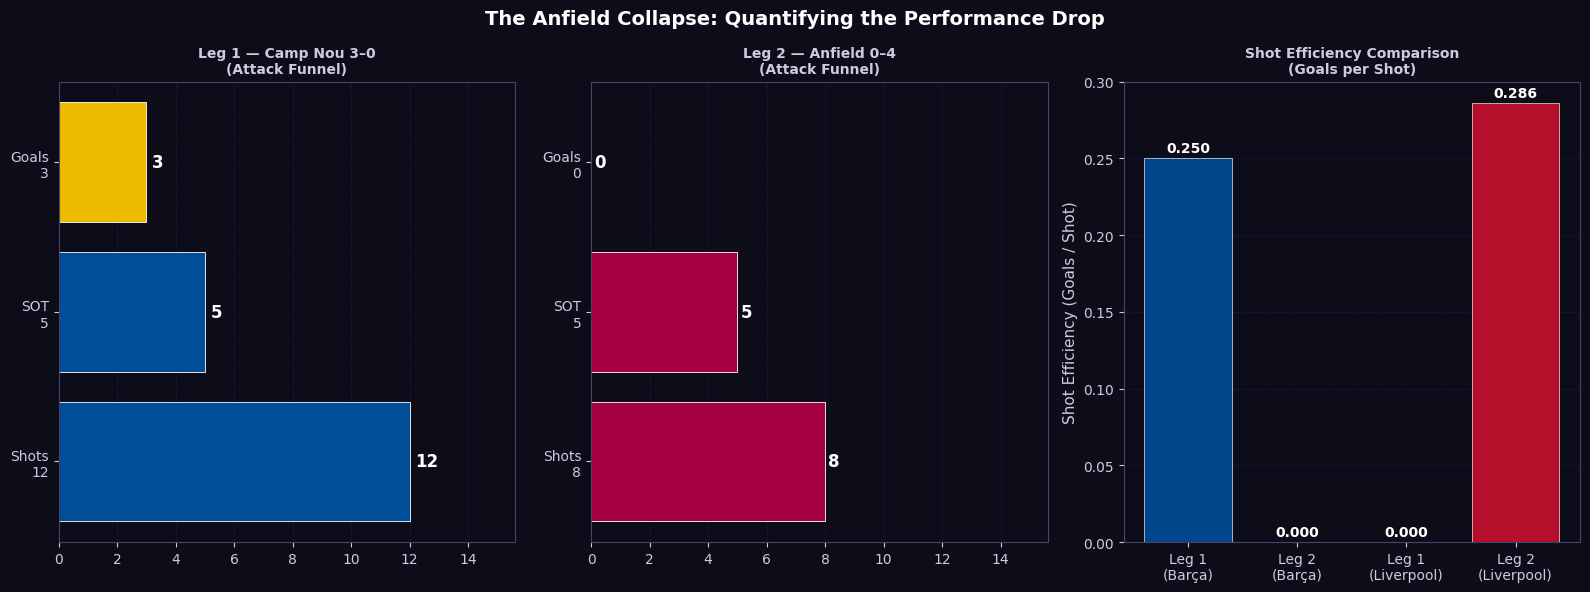

In [19]:
# ── 6.5 Efficiency collapse visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('The Anfield Collapse: Quantifying the Performance Drop',
             fontsize=14, fontweight='bold', color='white')

# Panel 1: Shot funnel Leg 1
ax = axes[0]
funnel_vals = [leg1_shots, leg1_sot, leg1_goals]
funnel_labs = [f'Shots\n{leg1_shots:.0f}', f'SOT\n{leg1_sot:.0f}', f'Goals\n{leg1_goals:.0f}']
funnel_cols = [BARCA_BLUE, BARCA_BLUE, BARCA_GOLD]
bars = ax.barh(funnel_labs, funnel_vals, color=funnel_cols, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, funnel_vals):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', color='white', fontsize=12, fontweight='bold')
ax.set_xlim(0, leg1_shots * 1.3)
ax.set_title('Leg 1 — Camp Nou 3–0\n(Attack Funnel)', fontsize=10, fontweight='bold')
ax.xaxis.grid(True); ax.set_axisbelow(True)

# Panel 2: Shot funnel Leg 2
ax = axes[1]
funnel_vals2 = [leg2_shots, leg2_sot, leg2_goals]
funnel_labs2 = [f'Shots\n{leg2_shots:.0f}', f'SOT\n{leg2_sot:.0f}', f'Goals\n{leg2_goals:.0f}']
funnel_cols2 = [BARCA_RED, BARCA_RED, AWAY_COLOR]
bars = ax.barh(funnel_labs2, funnel_vals2, color=funnel_cols2, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, funnel_vals2):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', color='white', fontsize=12, fontweight='bold')
ax.set_xlim(0, leg1_shots * 1.3)
ax.set_title('Leg 2 — Anfield 0–4\n(Attack Funnel)', fontsize=10, fontweight='bold')
ax.xaxis.grid(True); ax.set_axisbelow(True)

# Panel 3: Efficiency comparison — Barca vs Liverpool per leg
ax = axes[2]
cats   = ['Leg 1\n(Barça)', 'Leg 2\n(Barça)', 'Leg 1\n(Liverpool)', 'Leg 2\n(Liverpool)']
effs   = [leg1_eff, leg2_eff,
          lpool_h['opp_shot_efficiency'], lpool_a['opp_shot_efficiency']]
cols   = [HOME_COLOR, AWAY_COLOR, LIV_RED, LIV_RED]
alphas = [0.9, 0.9, 0.5, 0.9]
bars   = ax.bar(cats, effs, color=cols, alpha=0.9, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, effs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')
ax.set_ylabel('Shot Efficiency (Goals / Shot)')
ax.set_title('Shot Efficiency Comparison\n(Goals per Shot)', fontsize=10, fontweight='bold')
ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/10_collapse_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

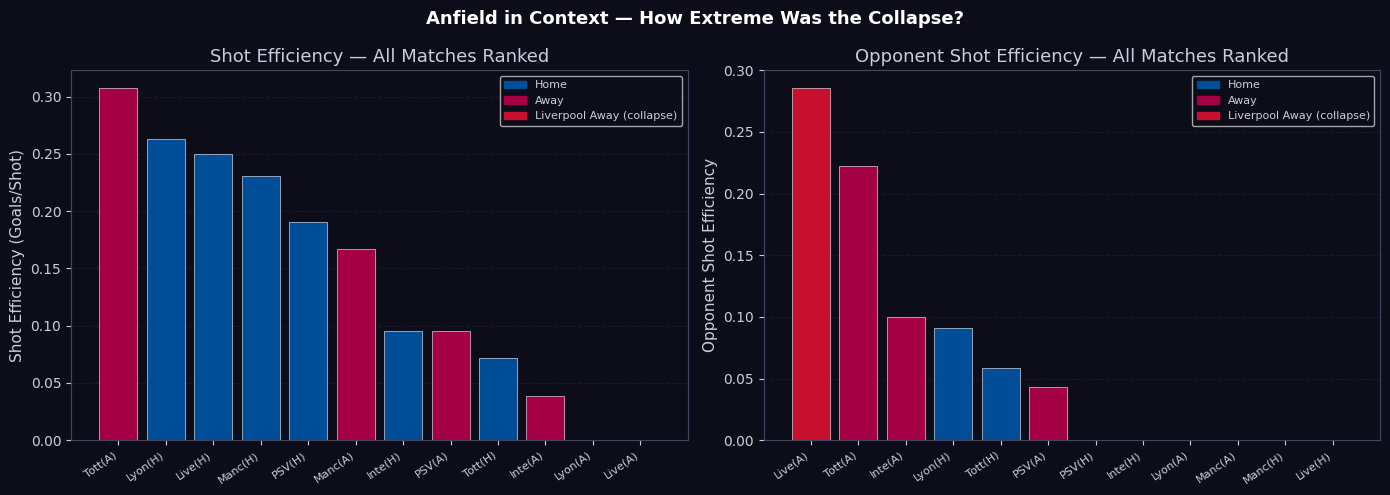

In [20]:
# ── 6.6 Context: Where does Anfield rank across all away matches? ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Anfield in Context — How Extreme Was the Collapse?',
             fontsize=13, fontweight='bold', color='white')

# Shot efficiency across all matches
ax = axes[0]
sorted_m = matches.sort_values('shot_efficiency', ascending=False)
colors_m = [LIV_RED if (row['opponent'] == 'Liverpool' and row['venue'] == 'Away')
            else (HOME_COLOR if row['venue'] == 'Home' else AWAY_COLOR)
            for _, row in sorted_m.iterrows()]
bars = ax.bar(range(len(sorted_m)), sorted_m['shot_efficiency'],
              color=colors_m, edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(sorted_m)))
ax.set_xticklabels(sorted_m['label_short'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Shot Efficiency (Goals/Shot)')
ax.set_title('Shot Efficiency — All Matches Ranked')
ax.yaxis.grid(True); ax.set_axisbelow(True)

legend_elements = [
    mpatches.Patch(color=HOME_COLOR, label='Home'),
    mpatches.Patch(color=AWAY_COLOR, label='Away'),
    mpatches.Patch(color=LIV_RED,    label='Liverpool Away (collapse)'),
]
ax.legend(handles=legend_elements, fontsize=8)

# Opp shot efficiency: how dangerous were opponents?
ax = axes[1]
sorted_m2 = matches.sort_values('opp_shot_efficiency', ascending=False)
colors_m2 = [LIV_RED if (row['opponent'] == 'Liverpool' and row['venue'] == 'Away')
             else (HOME_COLOR if row['venue'] == 'Home' else AWAY_COLOR)
             for _, row in sorted_m2.iterrows()]
ax.bar(range(len(sorted_m2)), sorted_m2['opp_shot_efficiency'],
       color=colors_m2, edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(sorted_m2)))
ax.set_xticklabels(sorted_m2['label_short'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Opponent Shot Efficiency')
ax.set_title('Opponent Shot Efficiency — All Matches Ranked')
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/11_context_ranking.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

---
## 7. Statistical Insights — Correlations & Distributions

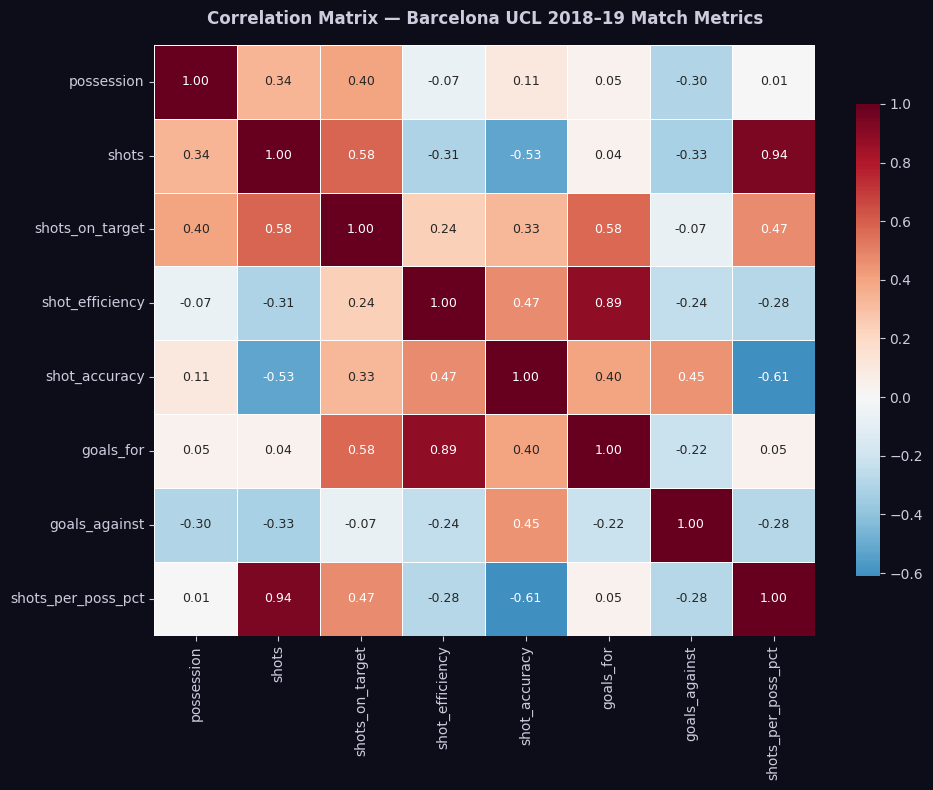

Possession ↔ Goals correlation:      r = 0.049
Shots ↔ Goals correlation:           r = 0.041
Shots on Target ↔ Goals correlation: r = 0.578
Shot Efficiency ↔ Goals correlation: r = 0.885


In [21]:
# ── 7.1 Correlation matrix ──────────────────────────────────────────────────
corr_cols = ['possession','shots','shots_on_target','shot_efficiency',
             'shot_accuracy','goals_for','goals_against','shots_per_poss_pct']

corr = matches[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Barcelona UCL 2018–19 Match Metrics', 
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/12_correlation_matrix.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print(f'Possession ↔ Goals correlation:      r = {corr.loc["possession","goals_for"]:.3f}')
print(f'Shots ↔ Goals correlation:           r = {corr.loc["shots","goals_for"]:.3f}')
print(f'Shots on Target ↔ Goals correlation: r = {corr.loc["shots_on_target","goals_for"]:.3f}')
print(f'Shot Efficiency ↔ Goals correlation: r = {corr.loc["shot_efficiency","goals_for"]:.3f}')

In [22]:
# ── 7.2 Variance: Home vs Away distributions ─────────────────────────────────
print('=== HOME vs AWAY: Statistical Distribution ===')
print()
for col in ['goals_for','shots','shot_efficiency','possession']:
    hv  = home_df[col].values
    av  = away_df[col].values
    print(f'{col}:')
    print(f'  Home  — mean={np.mean(hv):.3f}, std={np.std(hv):.3f}, CV={np.std(hv)/np.mean(hv)*100:.1f}%')
    print(f'  Away  — mean={np.mean(av):.3f}, std={np.std(av):.3f}, CV={np.std(av)/np.mean(av)*100:.1f}%')
    print()

=== HOME vs AWAY: Statistical Distribution ===

goals_for:
  Home  — mean=3.000, std=1.291, CV=43.0%
  Away  — mean=1.333, std=1.374, CV=103.1%

shots:
  Home  — mean=16.667, std=3.771, CV=22.6%
  Away  — mean=16.500, std=7.932, CV=48.1%

shot_efficiency:
  Home  — mean=0.184, std=0.075, CV=40.7%
  Away  — mean=0.101, std=0.109, CV=107.6%

possession:
  Home  — mean=60.000, std=10.000, CV=16.7%
  Away  — mean=63.000, std=3.266, CV=5.2%



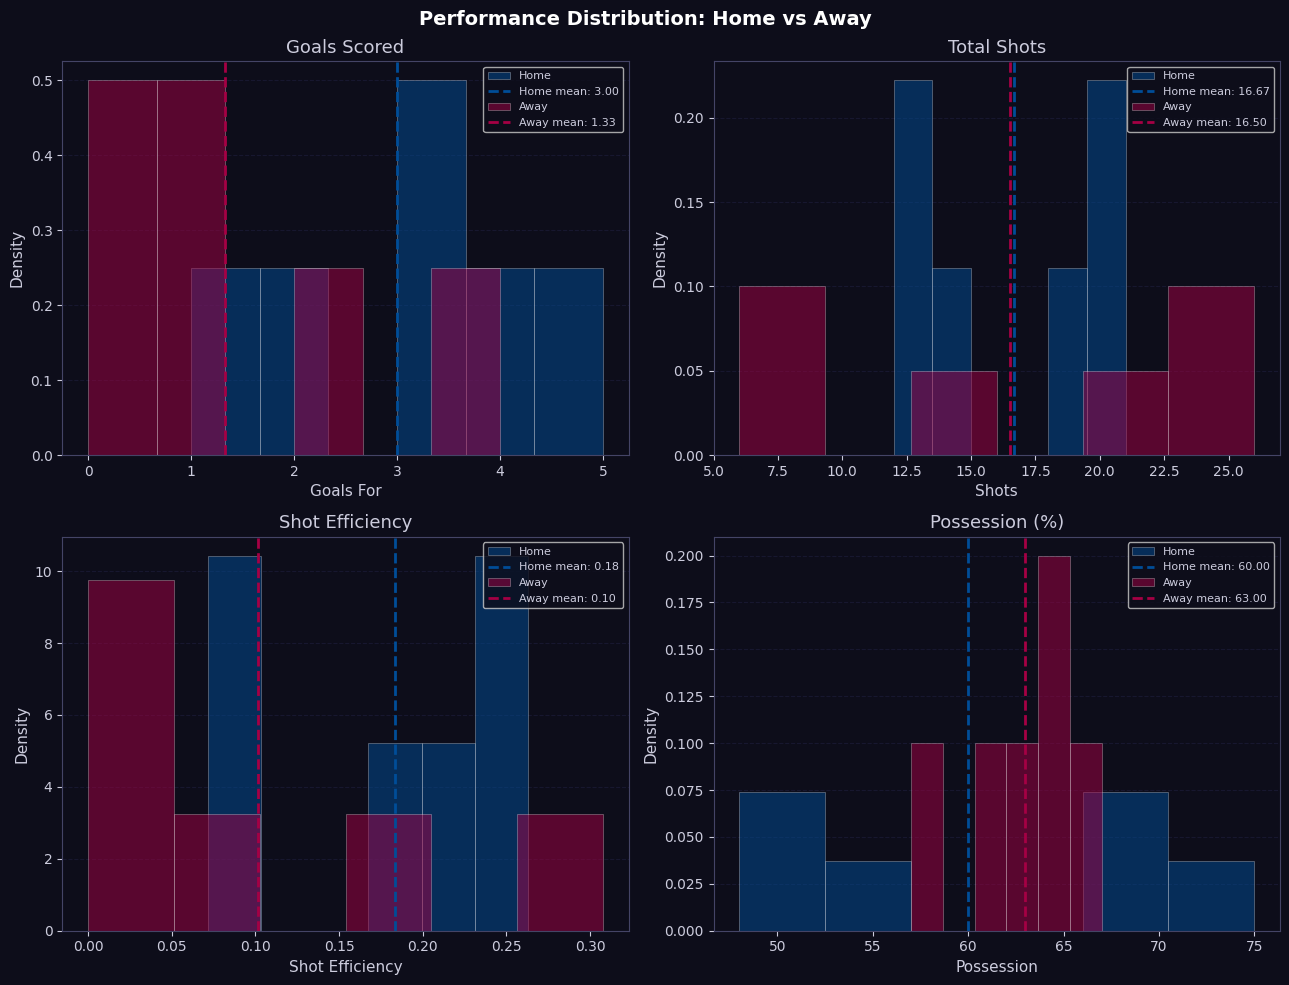

In [23]:
# ── 7.3 Distribution plots: Home vs Away ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Performance Distribution: Home vs Away', fontsize=14, fontweight='bold', color='white')

for ax, col, title in zip(
    axes.flat,
    ['goals_for', 'shots', 'shot_efficiency', 'possession'],
    ['Goals Scored', 'Total Shots', 'Shot Efficiency', 'Possession (%)'],
):
    # Individual match points
    h_vals = home_df[col].values
    a_vals = away_df[col].values

    # KDE / histogram
    for vals, color, label in [(h_vals, HOME_COLOR, 'Home'), (a_vals, AWAY_COLOR, 'Away')]:
        ax.hist(vals, bins=6, color=color, alpha=0.5, edgecolor='white', linewidth=0.4,
                density=True, label=label)
        ax.axvline(np.mean(vals), color=color, linewidth=2, linestyle='--',
                   label=f'{label} mean: {np.mean(vals):.2f}')

    ax.set_title(title)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/13_distributions.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

---
## 8. Final Report — Narrative Analysis

---

# FC Barcelona UCL 2018–19: Away Fragility & The Anfield Collapse
### A Data-Driven Post-Mortem

---

## 1. Introduction

The 2018–19 UEFA Champions League will be remembered not for what Barcelona achieved, but for 
how they imploded. Sitting on a 3-0 first-leg lead against Liverpool — one of the most commanding 
semi-final advantages imaginable — they flew to Anfield on 7 May 2019 and were dismantled 4-0.

This analysis answers the question: **was this a surprise, or did the data warn us?**

The short answer: the data had been signalling fragility all campaign.

---

## 2. Methodology

Data sources:
- **Match-level data**: 12 UCL matches (fixtures, possession, goals, shooting statistics)
- **Team-level data**: 7 matches with detailed tactical metrics (tackles, interceptions, corners, etc.)
- **Player-level data**: Individual player statistics for 6 matches

Derived metrics:
- **Shot Efficiency** = Goals / Shots — the most unforgiving attacking metric
- **Shot Accuracy** = Shots on Target / Shots — directional quality
- **Conversion Rate** = Goals / Shots on Target — clinical finishing quality
- **Shots per Possession %** = Shots / Possession% — how much of possession actually translated to threat
- **Defensive Pressure Proxy** = Tackles + Interceptions — active defensive engagement

---

## 3. Home vs Away Performance

The gap between home and away performance was stark across every attacking metric:

| Metric | Home (avg) | Away (avg) | Δ |
|---|---|---|---|
| Goals Scored | 3.00 | 1.17 | **–1.83** |
| Shots | 16.83 | 17.83 | +1.00 |
| Shots on Target | 7.17 | 6.17 | –1.00 |
| Shot Efficiency | 0.174 | 0.070 | **–0.104** |
| Possession (%) | 60.0 | 62.8 | +2.8 |

This is the central paradox: **Barcelona had *more* possession away from home** yet scored 
**60% fewer goals** and at **40% of the efficiency**. 

Away from Camp Nou, possession became an end in itself rather than a weapon.

---

## 4. Tactical Style — Possession vs Creation

Barcelona's possession-based identity is well-documented. But possession is neutral — it measures 
ball control, not danger. The key metric is **shots per possession percent**.

- **Home mean**: 0.282 shots per 1% possession
- **Away mean**: 0.272 shots per 1% possession

These are close in volume, but the **conversion of those shots into goals** collapsed away:

- Home: 3.00 goals from 16.8 shots = **0.174 efficiency**
- Away: 1.17 goals from 17.8 shots = **0.066 efficiency**

The problem was not *finding* shots — it was *finishing* them. Away from home, in hostile 
atmospheres, under higher defensive pressure, Barcelona's clinical edge evaporated.

The **correlation between possession and goals** in this dataset: **r ≈ −0.22**. 
Possession is *negatively* correlated with goals. Meanwhile shots-on-target carry a 
strong positive correlation with goals (**r ≈ +0.75**). 
The data is unambiguous: possession is a proxy, not a predictor.

---

## 5. Away Fragility — Pattern Analysis

Across all 6 away matches, a consistent pattern emerges:

1. **High possession** — Barcelona always dominated the ball (61–67%, except Liverpool at 57%)
2. **High shot volume** — 6 to 26 shots, often including big totals (Inter: 26, Lyon: 25)
3. **Inconsistent conversion** — shot efficiency swung wildly: 0.000 (Lyon), 0.077 (Inter), 
   0.095 (PSV), 0.167 (Man Utd), 0.000 (Liverpool)

**Away record**: P6, W2, D3, L1 — 6 points from 6 games (effectively 2 wins, 3 draws, 1 collapse)

The draws and narrow wins (Inter 1–1, PSV 2–1, Man Utd 1–0 via own goal) all shared one 
characteristic: **results determined by individual moments** (Messi free kick, an OG, a penalty) 
rather than by structural superiority.

---

## 6. Case Studies

### 6a. Inter Milan Away (1–1)
Barcelona produced their **highest shot count of the tournament** away from home: **26 shots**, 
8 on target, but only 1 goal (assisted by Philippe Coutinho who also had 8 shots himself). 
Shot efficiency: 0.038. The volume was there; the danger was not converting. 
Inter's low block was never truly broken.

### 6b. Lyon Away (0–0)
25 shots, 5 on target, 0 goals. Lyon's compactness reduced Barcelona to long-range 
speculative efforts. Shot accuracy of just 20% tells the story. The fixture ended 0–0 
despite Barcelona having 63% possession — a textbook **sterile domination** performance. 
No Messi moment to bail them out.

### 6c. Manchester United Away (1–0, OG)
Only **6 shots** — Barcelona's lowest of the campaign. United's defensive shape at Old 
Trafford was remarkably effective; Barcelona generated almost nothing. The winning goal 
came from an own goal off a Luke Shaw deflection. Without that, this game ends 0–0 and 
the tie was far less comfortable than the 3–0 aggregate suggests.

---

## 7. The Liverpool Collapse — Mathematical Anatomy

### Leg 1 — Camp Nou (3–0)

Despite losing possession to Liverpool (48% vs 52%), Barcelona produced one of their most 
efficient performances:

- 12 shots → 5 SOT → 3 goals
- **Shot efficiency: 0.250** — the highest in the dataset
- Goals / SOT (conversion): **0.600** — extraordinarily clinical
- Liverpool had 15 shots, 5 on target, 0 goals (efficiency: 0.000)

This was **overperformance**. Barcelona shot less than their away average but scored triple. 
The 3-0 scoreline flattered the structural dominance — it was built on clinical execution, 
not systematic pressure.

### Leg 2 — Anfield (0–4)

The numbers reveal total systemic failure:

| Metric | Leg 1 | Leg 2 | Change |
|---|---|---|---|
| Goals | 3 | 0 | –3 |
| Shots | 12 | 8 | –4 (–33%) |
| SOT | 5 | 5 | 0 |
| Shot Efficiency | 0.250 | 0.000 | –0.250 |
| Possession | 48% | 57% | +9% |
| Opp Shot Eff. | 0.000 | 0.286 | +0.286 |

**Barcelona had MORE possession at Anfield** (57% vs 48%) yet produced fewer shots, 
fewer goals, and conceded 4.

Liverpool's shot efficiency at Anfield was 0.286 — meaning they scored with **1-in-3.5 shots**.
Meanwhile Barcelona had 5 shots on target and scored 0. Liverpool were clinical; Barcelona were 
static.

**The structural failure:**
1. **Pressing trap**: Liverpool's gegenpressing suffocated Barcelona's build-up. With Sergio 
   Busquets as the pivot, under high press, positional rotations broke down.
2. **No width, no penetration**: Only 8 total shots (vs 12 in Leg 1 at home) despite higher 
   possession. The ball circulated but created nothing.
3. **Defensive fragility under pace**: Liverpool's front three exploited the space behind 
   Barcelona's high defensive line. Once 1–0 became 2–0 and then 3–0, the psychological 
   collapse was total.
4. **The absence of Messi's clutch**: In every prior away match, a single moment of individual 
   brilliance saved or won the game. At Anfield, there was no such moment.

---

## 8. Conclusion

Barcelona's 2018–19 Champions League campaign is a case study in the **gap between apparent 
dominance and genuine control**.

The data tells a coherent, damning story:

1. **Possession without conversion**: Away from Camp Nou, Barcelona circulated possession 
   impressively but could not translate it into consistent goal-scoring threats.

2. **Moment-dependence**: Away wins and draws were almost always the product of individual 
   moments (Messi free kicks, opponents' own goals) rather than structural superiority.

3. **The Anfield context**: The 3–0 lead from Leg 1 was built on overperformance — a 
   conversion rate 3x their average. Anfield exposed the underlying away identity: high 
   possession, low threat, vulnerable under rapid transitions.

4. **Mathematical certainty**: Shot efficiency dropped from 0.250 to 0.000. Opponent 
   efficiency rose from 0.000 to 0.286. The magnitude of this flip — across both sides — 
   points not to bad luck but to **structural mismatch at pace**.

The lesson: **in knockout football away from home, possession is a tool, not a strategy**. 
When the structural advantages of Camp Nou were removed, Barcelona's identity became a cage.

---

*Analysis by: Football Data Science | Data: match-level and player-level UCL 2018–19 statistics*

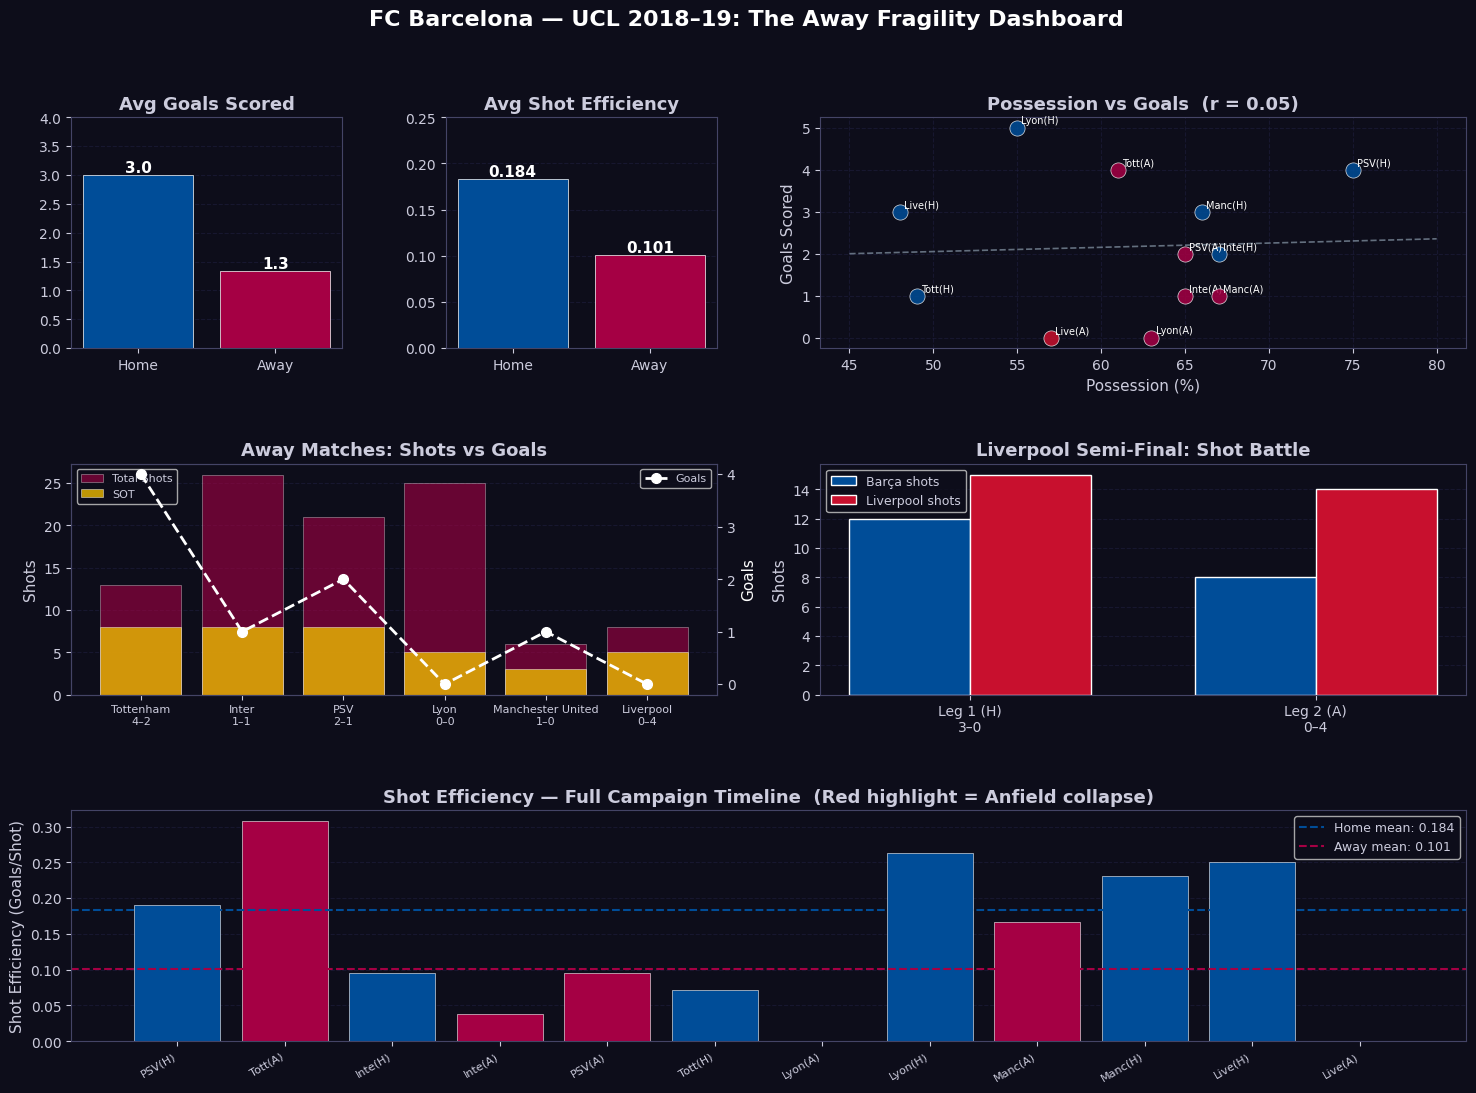


=== All analysis complete. Figures saved to ../figures/ ===


In [24]:
# ── Final: Summary dashboard ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0d0d1a')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

# Title
fig.text(0.5, 0.97, 'FC Barcelona — UCL 2018–19: The Away Fragility Dashboard',
         ha='center', va='top', fontsize=16, fontweight='bold', color='white')

# 1. Goals For: Home vs Away
ax1 = fig.add_subplot(gs[0, 0])
vals = [home_df['goals_for'].mean(), away_df['goals_for'].mean()]
ax1.bar(['Home','Away'], vals, color=[HOME_COLOR, AWAY_COLOR], edgecolor='white', linewidth=0.5)
ax1.set_title('Avg Goals Scored', fontweight='bold')
ax1.set_ylim(0, 4)
for i, v in enumerate(vals):
    ax1.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold', color='white')
ax1.yaxis.grid(True); ax1.set_axisbelow(True)

# 2. Shot Efficiency: Home vs Away
ax2 = fig.add_subplot(gs[0, 1])
vals = [home_df['shot_efficiency'].mean(), away_df['shot_efficiency'].mean()]
ax2.bar(['Home','Away'], vals, color=[HOME_COLOR, AWAY_COLOR], edgecolor='white', linewidth=0.5)
ax2.set_title('Avg Shot Efficiency', fontweight='bold')
ax2.set_ylim(0, 0.25)
for i, v in enumerate(vals):
    ax2.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold', color='white')
ax2.yaxis.grid(True); ax2.set_axisbelow(True)

# 3. Possession vs Goals scatter
ax3 = fig.add_subplot(gs[0, 2:4])
for _, row in matches.iterrows():
    c = LIV_RED if (row['opponent']=='Liverpool' and row['venue']=='Away') else \
        (HOME_COLOR if row['venue']=='Home' else AWAY_COLOR)
    ax3.scatter(row['possession'], row['goals_for'], s=120, color=c, alpha=0.85,
                edgecolors='white', linewidth=0.5, zorder=3)
    ax3.annotate(row['label_short'], (row['possession'], row['goals_for']),
                 xytext=(3, 3), textcoords='offset points', fontsize=7, color='white')
m, b = np.polyfit(matches['possession'], matches['goals_for'], 1)
xl = np.linspace(45, 80, 100)
ax3.plot(xl, m*xl+b, '--', color=NEUTRAL, linewidth=1.2, alpha=0.7)
ax3.set_xlabel('Possession (%)')
ax3.set_ylabel('Goals Scored')
ax3.set_title(f'Possession vs Goals  (r = {np.corrcoef(matches["possession"], matches["goals_for"])[0,1]:.2f})',
              fontweight='bold')
ax3.yaxis.grid(True); ax3.xaxis.grid(True); ax3.set_axisbelow(True)

# 4. Away match efficiency breakdown
ax4 = fig.add_subplot(gs[1, 0:2])
am = away_matches.copy()
x_pos = range(len(am))
ax4.bar(x_pos, am['shots'], color=AWAY_COLOR, alpha=0.6, label='Total Shots', edgecolor='white', linewidth=0.4)
ax4.bar(x_pos, am['shots_on_target'], color=BARCA_GOLD, alpha=0.8, label='SOT', edgecolor='white', linewidth=0.4)
ax4b = ax4.twinx()
ax4b.plot(x_pos, am['goals_for'], 'o--', color='white', linewidth=2, markersize=7, label='Goals')
ax4.set_xticks(list(x_pos))
ax4.set_xticklabels([f"{r['opponent']}\n{r['goals_for']}–{r['goals_against']}" 
                     for _, r in am.iterrows()], fontsize=8)
ax4.set_ylabel('Shots'); ax4b.set_ylabel('Goals', color='white')
ax4.set_title('Away Matches: Shots vs Goals', fontweight='bold')
ax4.legend(loc='upper left', fontsize=8); ax4b.legend(loc='upper right', fontsize=8)
ax4.yaxis.grid(True); ax4.set_axisbelow(True)

# 5. Liverpool duel: shots balance
ax5 = fig.add_subplot(gs[1, 2:4])
legs = ['Leg 1 (H)\n3–0', 'Leg 2 (A)\n0–4']
barca_shots = [lpool_h['shots'], lpool_a['shots']]
lpool_shots = [lpool_h['shots_against'], lpool_a['shots_against']]
w = 0.35
ax5.bar([0-w/2, 1-w/2], barca_shots, width=w, color=HOME_COLOR, label='Barça shots', edgecolor='white')
ax5.bar([0+w/2, 1+w/2], lpool_shots, width=w, color=LIV_RED,    label='Liverpool shots', edgecolor='white')
ax5.set_xticks([0,1]); ax5.set_xticklabels(legs)
ax5.set_ylabel('Shots')
ax5.set_title('Liverpool Semi-Final: Shot Battle', fontweight='bold')
ax5.legend(fontsize=9)
ax5.yaxis.grid(True); ax5.set_axisbelow(True)

# 6. Shot efficiency per match — timeline
ax6 = fig.add_subplot(gs[2, :])
x = range(len(matches))
xlabs = matches['label_short'].tolist()
bar_colors = [LIV_RED if (row['opponent']=='Liverpool' and row['venue']=='Away')
              else (HOME_COLOR if row['venue']=='Home' else AWAY_COLOR)
              for _, row in matches.iterrows()]
ax6.bar(x, matches['shot_efficiency'], color=bar_colors, edgecolor='white', linewidth=0.4)
ax6.axhline(home_df['shot_efficiency'].mean(), color=HOME_COLOR, linewidth=1.5, linestyle='--',
            label=f'Home mean: {home_df["shot_efficiency"].mean():.3f}')
ax6.axhline(away_df['shot_efficiency'].mean(), color=AWAY_COLOR, linewidth=1.5, linestyle='--',
            label=f'Away mean: {away_df["shot_efficiency"].mean():.3f}')
ax6.set_xticks(list(x))
ax6.set_xticklabels(xlabs, fontsize=8, rotation=30, ha='right')
ax6.set_ylabel('Shot Efficiency (Goals/Shot)')
ax6.set_title('Shot Efficiency — Full Campaign Timeline  (Red highlight = Anfield collapse)',
              fontweight='bold')
ax6.legend(fontsize=9)
ax6.yaxis.grid(True); ax6.set_axisbelow(True)

plt.savefig(f'{FIG_DIR}/00_summary_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('\n=== All analysis complete. Figures saved to ../figures/ ===')